# Thesis Analysis — Full Pipeline
**Promotions, Fashion Level, Store Frequency → Product Returns**

Run cells in order from top to bottom.

---
## Structure
- **Part 1:** Setup & Load
- **Part 2:** Data Cleaning & Fixes
- **Part 3:** EDA — Chapter 3 Numbers
- **Part 4:** Logistic Regression — Chapter 4
- **Part 5:** Predictive Analysis (RF + XGBoost) — Chapter 4

---
## PART 1: Setup & Load

In [1]:
# Install if needed
# %pip install pyreadstat statsmodels scikit-learn xgboost seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as scipy_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

FILE_PATH = '/Users/nhubui/Documents/Thesis/PurchaseAndReturnDataShoes.sav'
df = pd.read_spss(FILE_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 7,979 rows × 29 columns


---
## PART 2: Data Cleaning & Fixes

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Colour palette ─────────────────────────────────────────────────────────────
SLATE   = '#3A5F8A'
SLATE_M = '#5585B5'
SLATE_L = '#A8C4E0'
GRAY    = '#8A8A8A'
WHITE   = '#FFFFFF'

# ── Global rcParams ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         18,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

def apply_thesis_style(ax, title='', xlabel='', ylabel='', legend=False):
    if title:   ax.set_title(title, fontsize=22, fontweight='bold', pad=14, loc='left')
    if xlabel:  ax.set_xlabel(xlabel, fontsize=20, labelpad=12)
    if ylabel:  ax.set_ylabel(ylabel, fontsize=20, labelpad=12)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.tick_params(axis='both', labelsize=19, length=0)
    ax.set_facecolor('white')
    if legend:
        ax.legend(fontsize=19, frameon=False, handlelength=2, handletextpad=0.8)

def label_bars(ax, bars, fmt='{:.1f}%', color=None, pad=5):
    c = color or SLATE
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + pad * 0.01 * ax.get_ylim()[1],
                fmt.format(h), ha='center', va='bottom',
                fontsize=19, fontweight='bold', color=c)

def label_line(ax, xs, ys, fmt='{:.1f}%', color=None, offset=(0, 10)):
    c = color or SLATE
    for x, y in zip(xs, ys):
        ax.annotate(fmt.format(y), (x, y),
                    textcoords='offset points', xytext=offset,
                    ha='center', fontsize=18, fontweight='bold', color=c)

print('✓ Style setup complete.')


✓ Style setup complete.


In [ ]:
# Save raw copy before any cleaning
df_raw = df.copy()

# ── Fix 1: ItemReturn → numeric 0/1 ──────────────────────────────────────────
df['ItemReturn'] = df['ItemReturn'].map({'Return': 1, 'No return': 0})
df['ItemReturn'] = pd.to_numeric(df['ItemReturn'])

# ── Fix 2: OrderCoupon → binary (overwrite categorical with 0/1) ───────────────────────────────────────────────
df['OrderCoupon_3cat'] = df['OrderCoupon'].copy()   # preserve 3-category for robustness check 4.8
df['OrderCoupon'] = (df['OrderCoupon'] != 'No coupon used').astype(int)

# ── Fix 3: Fashion Level — missing, merge AVANT-GA → VERNIEUW ───────────
df['ItemFashionLevel'] = (
    df['ItemFashionLevel']
    .replace('', np.nan)
    .replace('AVANT-GA', 'VERNIEUW')
)
df = df.dropna(subset=['ItemFashionLevel'])
# 3 categories: ACTUEEL, NVT, VERNIEUW  |  NVT = reference

# ── Fix 4: ItemPrice log-transform ───────────────────────────────────────────
df['ItemPrice'] = pd.to_numeric(df['ItemPrice'], errors='coerce')
df['ItemPrice_log'] = np.log1p(df['ItemPrice'])

# ── Fix 5: Day of week — data is string (Monday, Tuesday...)
df['Day'] = df['Day'].replace('', np.nan)
print(f"Day distribution after fix:")
print(df['Day'].value_counts().sort_index())
print(f"Day NaN: {df['Day'].isna().sum()}")

# ── Fix 6: Mean-center Storefrequency SAU KHI filter ─────────────────────────
df['Storefrequency_centered'] = df['Storefrequency'] - df['Storefrequency'].mean()

# ── Verification ──────────────────────────────────────────────────────────────
print('\n✓ All fixes applied')
print(f"Observations after filter: {len(df):,}  (removed 929 unclassified)")
print(f"Return rate:               {df['ItemReturn'].mean()*100:.2f}%")
print(f"OrderCoupon rate:           {df['OrderCoupon'].mean()*100:.1f}%")
print(f"Fashion Level categories:  {sorted(df['ItemFashionLevel'].unique())}")
print(f"ItemPrice_log mean:        {df['ItemPrice_log'].mean():.3f}")
print(f"ItemPrice_log ↔ ItemReturn corr: {df[['ItemPrice_log','ItemReturn']].corr().iloc[0,1]:.3f}")
print(f"Storefrequency_centered mean:    {df['Storefrequency_centered'].mean():.6f}")


Day distribution after fix:
Day
Friday        820
Monday       1014
Saturday      917
Sunday       1154
Thursday      906
Tuesday       921
Wednesday    1318
Name: count, dtype: int64
Day NaN: 0

✓ All fixes applied
Observations after filter: 7,050  (removed 929 unclassified)
Return rate:               18.55%
OrderCoupon rate:           7.8%
Fashion Level categories:  ['ACTUEEL', 'NVT', 'VERNIEUW']
ItemPrice_log mean:        3.856
ItemPrice_log ↔ ItemReturn corr: 0.099
Storefrequency_centered mean:    -0.000000


---
## PART 2B: Data Structure Exploration

In [4]:
# ── 2B: Data Structure Exploration — ItemClass & FashionLevel ────────────────
# Cross-tabs to infer category meanings from raw data
# Requires df_raw (saved before cleaning)

print("ItemClass × ItemProductGroup:")
print(pd.crosstab(df_raw['ItemClass'], df_raw['ItemProductGroup']))

print("\nItemClass × ItemDepartment:")
print(pd.crosstab(df_raw['ItemClass'], df_raw['ItemDepartment']))

print("\nItemClass × ItemStylegroup:")
print(pd.crosstab(df_raw['ItemClass'], df_raw['ItemStylegroup']))

print("\nItemFashionLevel × ItemClass:")
print(pd.crosstab(df_raw['ItemFashionLevel'], df_raw['ItemClass']))

# Sample items per class to infer meaning
for cls in sorted(df_raw['ItemClass'].dropna().unique()):
    sub = (
        df_raw[df_raw['ItemClass'] == cls]
        [['ItemDescription', 'ItemProductGroup', 'ItemDepartment']]
        .dropna()
        .head(5)
    )
    print(f"\nItemClass = {cls}:")
    print(sub.to_string())


ItemClass × ItemProductGroup:
ItemProductGroup        BAG  BELTS  BOOT  BOOTEE  CLEARING  FUN  HATS  \
ItemClass                                                               
                  929     0      0     0       0         0    0     0   
ACCESSOI            0     0     38     0       0         0   10     3   
CLEARING            0     0      0     0       0      3086    0     0   
MODERN              0     0      0    96     413         0    0     0   
POPULAIR            0     0      0     8       7         0    0     0   
SHOE CAR            0     0      0     0       0         0    0     0   
STREET              0     0      0     1      50         0    0     0   
TRENDY              0  1426      0   134     508         0    0     0   

ItemProductGroup  HEELSAND  INLEGZOO  ...  LOAFER/B  PARTY BA  PUMP  SANDAL  \
ItemClass                             ...                                     
                         0         0  ...         0         0     0       0   
AC

In [5]:
pd.crosstab(df_raw['ItemFashionLevel'], df_raw['ItemClass'])
pd.crosstab(df_raw['ItemFashionLevel'], df_raw['ItemDepartment'])

ItemDepartment,,ACCESSOR,BAGS,LADIES,MEN,SHOE CAR
ItemFashionLevel,,,,,,
,929,0,0,0,0,0
ACTUEEL,0,21,226,2798,894,0
AVANT-GA,0,0,0,0,7,0
NVT,0,395,1142,0,0,30
VERNIEUW,0,14,58,1283,182,0


---
## PART 3: EDA — Chapter 3 Numbers

In [6]:
# ── 3.1 Sample Composition (Section 3.2) ─────────────────────────────────────
print('── SAMPLE COMPOSITION ──')
print(f"Total observations:  {len(df):,}")
print(f"  (929 obs without fashion level classification excluded)")
print(f"Unique customers:    {df['CustomerID'].nunique():,}")
print(f"Unique orders:       {df['OrderID'].nunique():,}")
print(f"Year range:          {int(df['Year'].min())}–{int(df['Year'].max())}")
print(f"Overall return rate: {df['ItemReturn'].mean()*100:.2f}%")


── SAMPLE COMPOSITION ──
Total observations:  7,050
  (929 obs without fashion level classification excluded)
Unique customers:    3,582
Unique orders:       5,651
Year range:          2013–2019
Overall return rate: 18.55%


In [7]:
# ── 3.2 Promotional Instruments (Section 3.3) ─────────────────────────────────
print('── PROMOTIONAL INSTRUMENTS ──')

print('\nItemDiscount:')
print(df['ItemDiscount'].describe(percentiles=[.5, .75, .95]).round(2))
print(f"Items with any discount: {(df['ItemDiscount'] > 0).mean()*100:.1f}%")

print('\nCoupon breakdown (original 3 categories):')
print(df['OrderCoupon'].value_counts())

print('\nReturn rate by coupon type:')
coupon_stats = df.groupby('OrderCoupon')['ItemReturn'].agg(n='count', return_rate='mean')
coupon_stats['return_rate'] = coupon_stats['return_rate'].mul(100).round(2)
print(coupon_stats)

── PROMOTIONAL INSTRUMENTS ──

ItemDiscount:
count    7050.00
mean        3.72
std        10.11
min         0.00
50%         0.00
75%         0.00
95%        22.50
max       104.99
Name: ItemDiscount, dtype: float64
Items with any discount: 19.6%

Coupon breakdown (original 3 categories):
OrderCoupon
0    6500
1     550
Name: count, dtype: int64

Return rate by coupon type:
                n  return_rate
OrderCoupon                   
0            6500        18.26
1             550        22.00


In [8]:
# ── 3.3 Moderators (Section 3.3) ──────────────────────────────────────────────
print('── MODERATORS ──')

print('\nFashion Level — distribution and return rate (3 categories, NVT = reference):')
fl = df.groupby('ItemFashionLevel')['ItemReturn'].agg(n='count', return_rate='mean')
fl['return_rate'] = fl['return_rate'].mul(100).round(2)
print(fl.sort_values('return_rate', ascending=False))

print('\nStorefrequency:')
sf = df['Storefrequency']
print(f"  mean={sf.mean():.3f}, median={sf.median():.0f}, std={sf.std():.3f}")
print(f"  zero store visits: {(sf == 0).mean()*100:.1f}%")
print(f"  any store visits:  {(sf > 0).mean()*100:.1f}%")
print(f"  value counts:\n{sf.value_counts().sort_index()}")


── MODERATORS ──

Fashion Level — distribution and return rate (3 categories, NVT = reference):
                     n  return_rate
ItemFashionLevel                   
VERNIEUW          1544        22.41
ACTUEEL           3939        20.03
NVT               1567        11.04

Storefrequency:
  mean=0.145, median=0, std=0.539
  zero store visits: 89.9%
  any store visits:  10.1%
  value counts:
Storefrequency
0.0    6336
1.0     545
2.0     107
3.0      25
4.0      24
6.0       2
7.0      11
Name: count, dtype: int64


In [9]:
# ── 3.4 Control Variables (Section 3.3) ────────────────────────────────────────
# Note: ItemEndUse excluded — overlaps perfectly with ItemFashionLevel (NVT=NVT)
print('── CONTROL VARIABLES ──')

ctrl_cols = ['WebshopFrequency', 'OrderValue', 'OrderItems', 'Age']
print(df[ctrl_cols].describe(percentiles=[.5]).round(2))

print('\nGender breakdown + return rate:')
print(df.groupby('Gender')['ItemReturn'].agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2)))

print('\nReturn rate by Year:')
print(df.groupby('Year')['ItemReturn'].agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2)))

print('\nItemClass distribution + return rate:')
print(df.groupby('ItemClass')['ItemReturn'].agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
      .sort_values('return_rate', ascending=False))


── CONTROL VARIABLES ──
       WebshopFrequency  OrderValue  OrderItems      Age
count           7050.00     7050.00     7050.00  7050.00
mean               2.21       87.83        1.59    29.04
std                1.80       76.44        1.04    10.53
min                0.00        1.00        1.00    14.00
50%                2.00       69.98        1.00    26.00
max               10.00     1094.90       10.00    82.00

Gender breakdown + return rate:
           n  return_rate
Gender                   
Female  6114        19.37
Male     936        13.25

Return rate by Year:
           n  return_rate
Year                     
2013.0    29        10.34
2014.0    82         8.54
2015.0   197        12.69
2016.0   735        17.82
2017.0  3763        16.85
2018.0   984        20.02
2019.0  1260        24.68

ItemClass distribution + return rate:
              n  return_rate
ItemClass                   
POPULAIR     58        29.31
MODERN      862        24.25
CLEARING   3086        20.54


In [10]:
# ── 3.5 Summary Statistics Table (Table 3) ────────────────────────────────────
print('── SUMMARY STATISTICS TABLE ──')
print(f"n = {len(df):,} item-level observations")

summary_cols = ['ItemDiscount', 'ItemPrice', 'Storefrequency',
                'WebshopFrequency', 'OrderValue', 'OrderItems', 'Age']
table = df[summary_cols].agg(['mean', 'std', 'median', 'min', 'max']).round(2)
print(table)
print(f"\nItemReturn: {df['ItemReturn'].mean()*100:.2f}%")
print(f"OrderCoupon rate: {df['OrderCoupon'].mean()*100:.1f}%")

print('\nFashion Level distribution:')
print(df['ItemFashionLevel'].value_counts())

print('\nReturn rate by Day of week:')
print(df.groupby('Day')['ItemReturn'].agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2)))


── SUMMARY STATISTICS TABLE ──
n = 7,050 item-level observations
        ItemDiscount  ItemPrice  Storefrequency  WebshopFrequency  OrderValue  \
mean            3.72      57.72            0.14              2.21       87.83   
std            10.11      36.67            0.54              1.80       76.44   
median          0.00      50.00            0.00              2.00       69.98   
min             0.00       0.00            0.00              0.00        1.00   
max           104.99     440.00            7.00             10.00     1094.90   

        OrderItems    Age  
mean          1.59  29.04  
std           1.04  10.53  
median        1.00  26.00  
min           1.00  14.00  
max          10.00  82.00  

ItemReturn: 18.55%
OrderCoupon rate: 7.8%

Fashion Level distribution:
ItemFashionLevel
ACTUEEL     3939
NVT         1567
VERNIEUW    1544
Name: count, dtype: int64

Return rate by Day of week:
              n  return_rate
Day                         
Friday      820        19.3

### 3.5 Subgroup Return Rates (Table A2)

In [11]:
print("=== Return Rate by ItemClass ===")
print(df.groupby('ItemClass', observed=True)['ItemReturn']
      .agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
      .to_string())

print("\n=== Return Rate by Gender ===")
print(df.groupby('Gender', observed=True)['ItemReturn']
      .agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
      .to_string())

print("\n=== Return Rate by Discount Type ===")
print(df.groupby('ItemDiscountType', observed=True)['ItemReturn']
      .agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
      .to_string())

print("\n=== Return Rate by Year ===")
print(df.groupby('Year', observed=True)['ItemReturn']
      .agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
      .to_string())

print("\n=== Return Rate by StoreVisitor ===")
store_visitor = (df['Storefrequency'] > 0).astype(int).rename('StoreVisitor')
print(df.groupby(store_visitor, observed=True)['ItemReturn']
      .agg(n='count', return_rate='mean')
      .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
      .rename(index={0: 'Online-only (0)', 1: 'Store visitor (1)'})
      .to_string())

=== Return Rate by ItemClass ===
              n  return_rate
ItemClass                   
ACCESSOI    430         8.84
CLEARING   3086        20.54
MODERN      862        24.25
POPULAIR     58        29.31
SHOE CAR     30        13.33
STREET      232        18.53
TRENDY     2352        15.43

=== Return Rate by Gender ===
           n  return_rate
Gender                   
Female  6114        19.37
Male     936        13.25

=== Return Rate by Discount Type ===
                     n  return_rate
ItemDiscountType                   
                  5675        19.01
CURRENCY           130        28.46
HRG               1075        14.14
PERCENTA           170        23.53

=== Return Rate by Year ===
           n  return_rate
Year                     
2013.0    29        10.34
2014.0    82         8.54
2015.0   197        12.69
2016.0   735        17.82
2017.0  3763        16.85
2018.0   984        20.02
2019.0  1260        24.68

=== Return Rate by StoreVisitor ===
                 

---
### Chapter 3 Figures

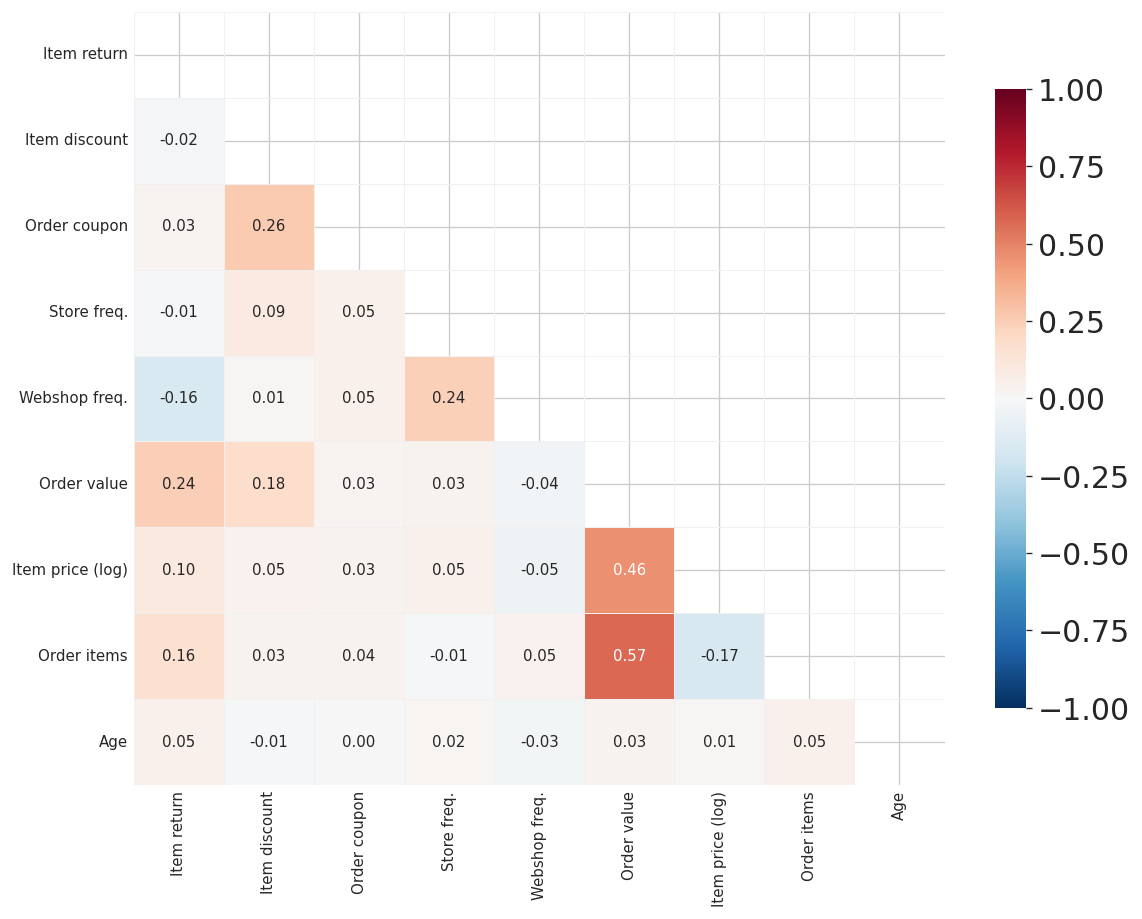

Saved: fig6_correlation_matrix.png


In [12]:
# Ensure OrderCoupon is numeric (binary) for correlation
df['OrderCoupon'] = (df['OrderCoupon'] != 'No coupon used').astype(int) \
    if df['OrderCoupon'].dtype == 'object' else df['OrderCoupon']

corr_cols = ['ItemReturn', 'ItemDiscount', 'OrderCoupon', 'Storefrequency',
             'WebshopFrequency', 'OrderValue', 'ItemPrice_log', 'OrderItems', 'Age']
corr_labels = ['Item return', 'Item discount', 'Order coupon', 'Store freq.',
               'Webshop freq.', 'Order value', 'Item price (log)', 'Order items', 'Age']

corr = df[corr_cols].apply(pd.to_numeric, errors='coerce').corr().round(3)
corr.index   = corr_labels
corr.columns = corr_labels

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='#F0F0F0',
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8},
            ax=ax)
#ax.set_title('Correlation matrix', fontsize=13, fontweight='bold', pad=12, loc='left')
ax.tick_params(axis='both', labelsize=9, length=0)
plt.tight_layout()
plt.savefig('fig6_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig6_correlation_matrix.png')


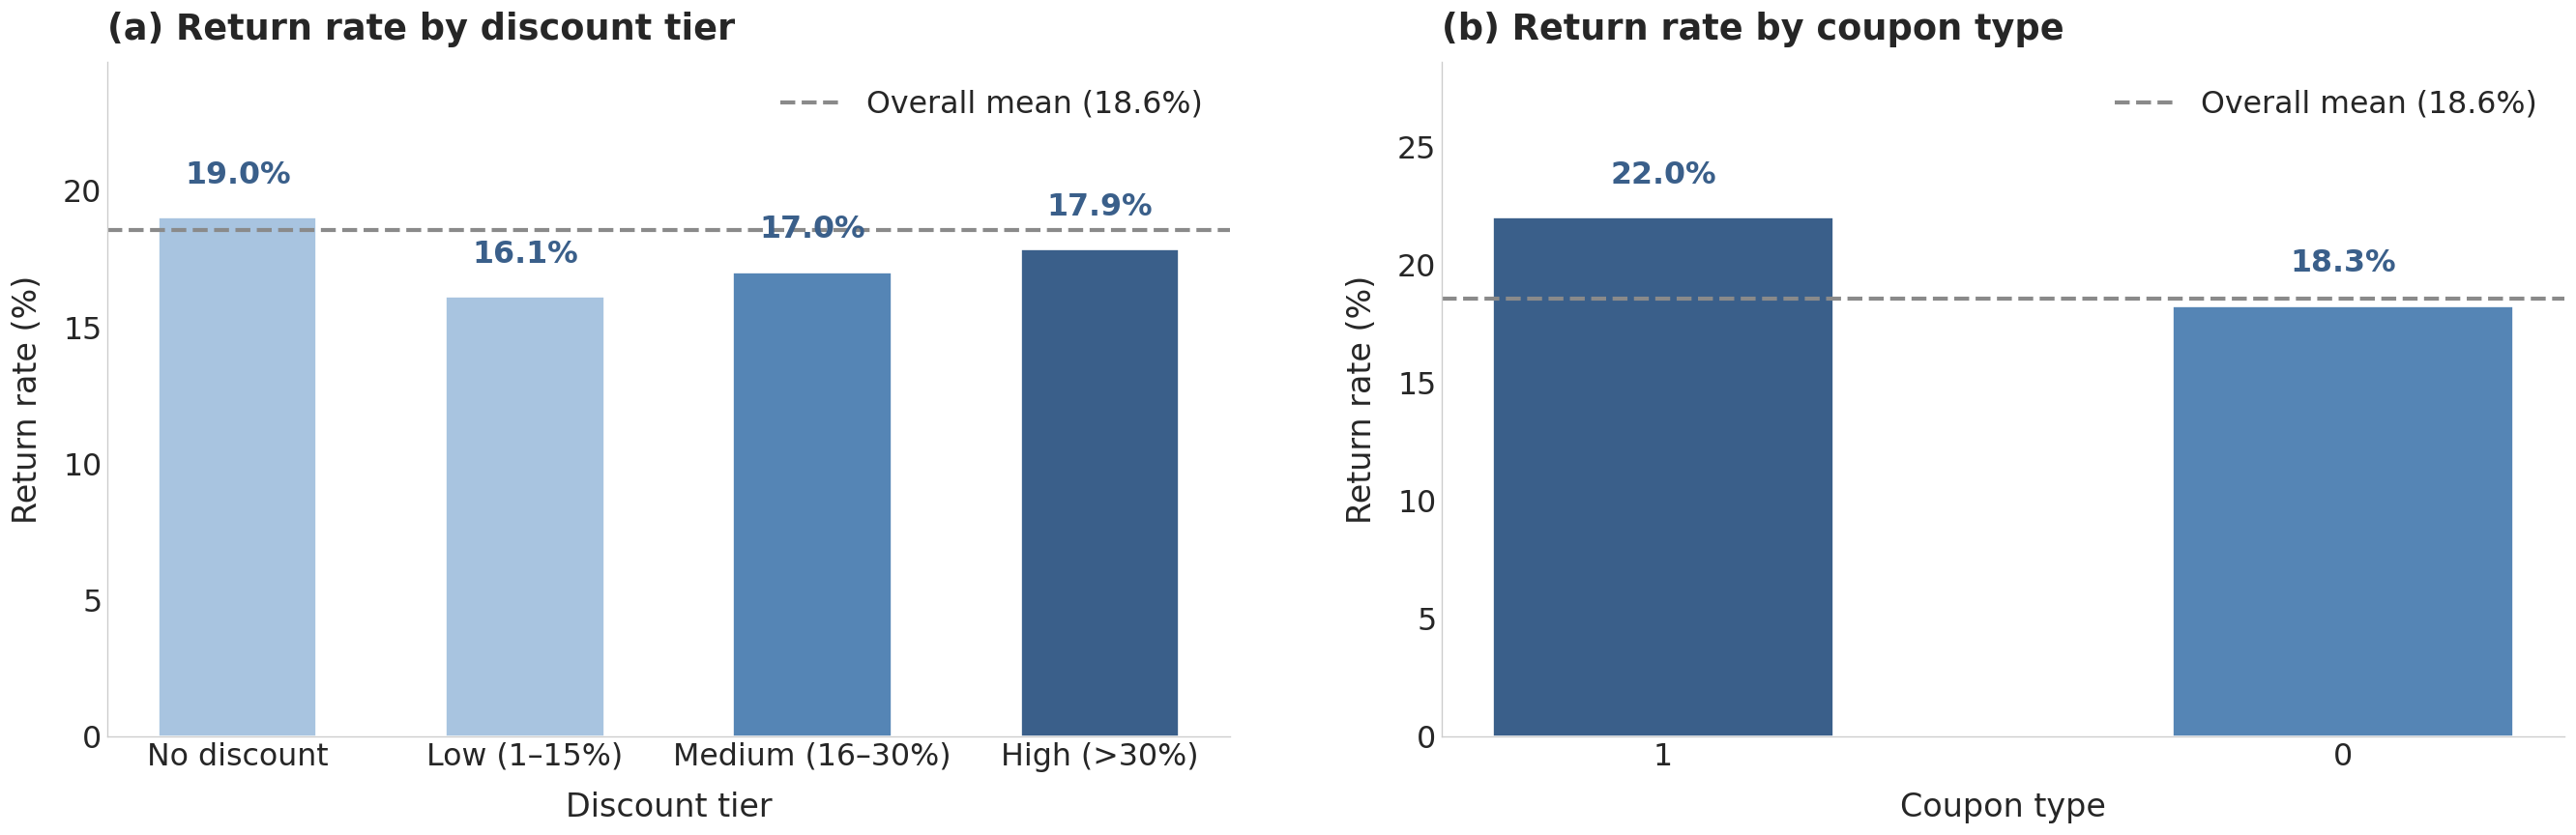

Saved: fig2_promotional_instruments — PNG + SVG


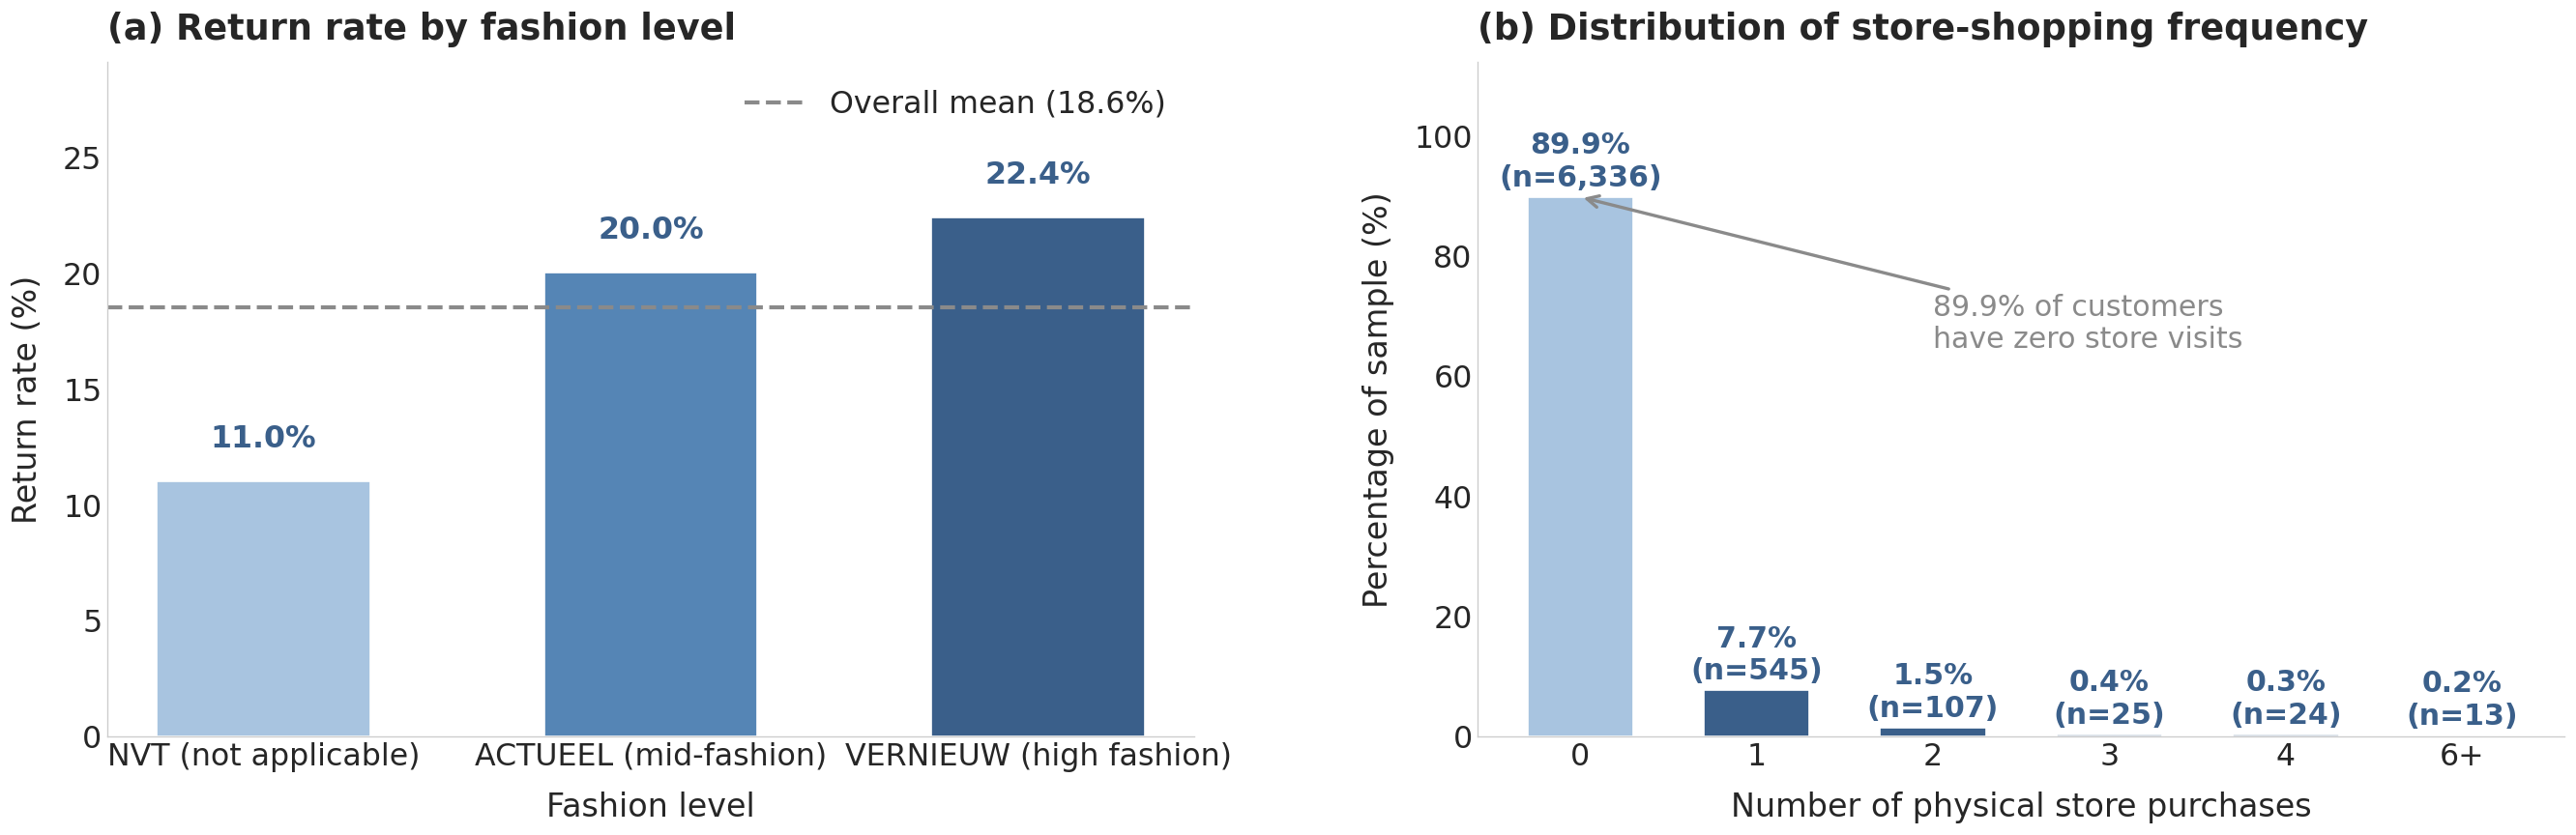

Saved: fig3_moderators — PNG + SVG


In [13]:
# ── Data preparation ──────────────────────────────────────────────────────────
fl = (
    df.groupby('ItemFashionLevel', observed=True)['ItemReturn']
    .agg(n='count', return_rate='mean')
    .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
    .reset_index()
)
fl_order  = ['NVT', 'ACTUEEL', 'VERNIEUW']
fl_labels = ['NVT (not applicable)', 'ACTUEEL (mid-fashion)', 'VERNIEUW (high fashion)']
fl        = fl.set_index('ItemFashionLevel').loc[fl_order].reset_index()

coupon_plot = (
    df.groupby('OrderCoupon', observed=True)['ItemReturn']
    .agg(n='count', return_rate='mean')
    .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
    .reset_index()
)
coupon_plot['label'] = coupon_plot['OrderCoupon'].astype(str).map({
    'No coupon used':      'No coupon\n(n=6,500)',
    'General coupon':      'General coupon\n(n=285)',
    'Personalized coupon': 'Personalized coupon\n(n=265)'
}).fillna(coupon_plot['OrderCoupon'].astype(str))
coupon_plot = coupon_plot.sort_values('return_rate', ascending=False).reset_index(drop=True)

sf_agg = {}
for v, c in df['Storefrequency'].value_counts().sort_index().items():
    key = '6+' if v >= 6 else str(int(v))
    sf_agg[key] = sf_agg.get(key, 0) + c
sf_keys   = list(sf_agg.keys())
sf_counts = list(sf_agg.values())
sf_pcts   = [v / len(df) * 100 for v in sf_counts]

if 'DiscBucket' not in df.columns:
    df['DiscBucket'] = pd.cut(df['ItemDiscount'],
        bins=[-0.01, 0, 15, 30, 200],
        labels=['No discount', 'Low (1–15%)', 'Medium (16–30%)', 'High (>30%)'])
buck = (
    df.groupby('DiscBucket', observed=True)['ItemReturn']
    .agg(n='count', return_rate='mean')
    .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
    .reset_index()
)

overall_mean = df['ItemReturn'].mean() * 100


# ── Figure 2: Promotional Instruments — Discount tier (a) + Coupon type (b) ──
fig2, axes2 = plt.subplots(1, 2, figsize=(24, 9))

ax = axes2[0]
bars = ax.bar(buck['DiscBucket'].astype(str), buck['return_rate'],
              color=[SLATE_L, SLATE_L, SLATE_M, SLATE][:len(buck)],
              edgecolor=WHITE, width=0.55)
label_bars(ax, bars, color=SLATE)
ax.axhline(overall_mean, color=GRAY, linestyle='--', linewidth=2.5,
           label=f'Overall mean ({overall_mean:.1f}%)')
ax.set_ylim(0, buck['return_rate'].max() * 1.3)
apply_thesis_style(ax,
    title='(a) Return rate by discount tier',
    xlabel='Discount tier', ylabel='Return rate (%)', legend=True)

ax = axes2[1]
bars = ax.bar(coupon_plot['label'], coupon_plot['return_rate'],
              color=[SLATE, SLATE_M, SLATE_L][:len(coupon_plot)],
              edgecolor=WHITE, width=0.5)
label_bars(ax, bars, color=SLATE)
ax.axhline(overall_mean, color=GRAY, linestyle='--', linewidth=2.5,
           label=f'Overall mean ({overall_mean:.1f}%)')
ax.set_ylim(0, coupon_plot['return_rate'].max() * 1.3)
apply_thesis_style(ax,
    title='(b) Return rate by coupon type',
    xlabel='Coupon type', ylabel='Return rate (%)', legend=True)

plt.tight_layout(pad=4.0)
plt.savefig('fig2_promotional_instruments.png', dpi=300, bbox_inches='tight')
plt.savefig('fig2_promotional_instruments.svg', bbox_inches='tight')
plt.show()
print('Saved: fig2_promotional_instruments — PNG + SVG')


# ── Figure 3: Moderators — Fashion level (a) + Store frequency (b) ────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(24, 9))

ax = axes3[0]
bars = ax.bar(fl_labels, fl['return_rate'],
              color=[SLATE_L, SLATE_M, SLATE], edgecolor=WHITE, width=0.55)
label_bars(ax, bars, color=SLATE)
ax.axhline(overall_mean, color=GRAY, linestyle='--', linewidth=2.5,
           label=f'Overall mean ({overall_mean:.1f}%)')
ax.set_ylim(0, fl['return_rate'].max() * 1.3)
apply_thesis_style(ax,
    title='(a) Return rate by fashion level',
    xlabel='Fashion level', ylabel='Return rate (%)', legend=True)

ax = axes3[1]
sf_colors = [SLATE_L if k == '0' else SLATE for k in sf_keys]
bars = ax.bar(sf_keys, sf_pcts, color=sf_colors, edgecolor=WHITE, width=0.6)
for bar, pct, n in zip(bars, sf_pcts, sf_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{pct:.1f}%\n(n={n:,})',
            ha='center', va='bottom',
            fontsize=18, fontweight='bold', color=SLATE)
ax.annotate('89.9% of customers\nhave zero store visits',
            xy=(0, sf_pcts[0]), xytext=(2, sf_pcts[0] * 0.72),
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=2.0),
            fontsize=18, color=GRAY)
ax.set_ylim(0, max(sf_pcts) * 1.25)
apply_thesis_style(ax,
    title='(b) Distribution of store-shopping frequency',
    xlabel='Number of physical store purchases',
    ylabel='Percentage of sample (%)')

plt.tight_layout(pad=4.0)
plt.savefig('fig3_moderators.png', dpi=300, bbox_inches='tight')
plt.savefig('fig3_moderators.svg', bbox_inches='tight')
plt.show()
print('Saved: fig3_moderators — PNG + SVG')


In [14]:
# ── Chapter 3 Figure Summary ─────────────────────────────────────────────────
print('Chapter 3 — Figures saved:')
print('  correlation_matrix.png          — Figure [X]: Correlation matrix')
print('  return_by_fashion_level.png     — Figure [X]: Return rate by fashion level')
print('  fig2_return_by_coupon_type.png  — Figure [X]: Return rate by coupon type')
print('  fig3_return_by_year.png         — Figure [X]: Return rate trend by year')
print('  fig4_store_frequency_dist.png   — Figure [X]: Store-shopping frequency distribution')
print('  fig5_return_by_discount_bucket.png — Figure [X]: Return rate by discount tier')
print()
print('Chapter 4 — Figures saved (Part 5 & 6):')
print('  feature_importance.png          — Figure [X]: RF vs XGBoost importance')
print('  pred_prob_discount_fl.png       — Figure [X]: Predicted prob discount x fashion level')
print('  pred_prob_coupon_fl.png         — Figure [X]: Predicted prob coupon x fashion level')
print('  store_visitor_subgroup.png      — Figure [X]: Store visitor subgroup analysis')
print('  discount_bucket_analysis.png    — Figure [X]: Discount bucket regression')
print('  year_trend_analysis.png         — Figure [X]: Year trend (Part 6)')
print('  gender_promotion_analysis.png   — Figure [X]: Gender x promotion')
print('  order_level_analysis.png        — Figure [X]: Order-level coupon analysis')


Chapter 3 — Figures saved:
  correlation_matrix.png          — Figure [X]: Correlation matrix
  return_by_fashion_level.png     — Figure [X]: Return rate by fashion level
  fig2_return_by_coupon_type.png  — Figure [X]: Return rate by coupon type
  fig3_return_by_year.png         — Figure [X]: Return rate trend by year
  fig4_store_frequency_dist.png   — Figure [X]: Store-shopping frequency distribution
  fig5_return_by_discount_bucket.png — Figure [X]: Return rate by discount tier

Chapter 4 — Figures saved (Part 5 & 6):
  feature_importance.png          — Figure [X]: RF vs XGBoost importance
  pred_prob_discount_fl.png       — Figure [X]: Predicted prob discount x fashion level
  pred_prob_coupon_fl.png         — Figure [X]: Predicted prob coupon x fashion level
  store_visitor_subgroup.png      — Figure [X]: Store visitor subgroup analysis
  discount_bucket_analysis.png    — Figure [X]: Discount bucket regression
  year_trend_analysis.png         — Figure [X]: Year trend (Part 6)
  g

---
## PART 3B: Pre-Modeling Diagnostics — Section 3.5

*Note: Check 1 (imbalance), Check 2 (missing), Check 3 (outliers) run here. The outlier sensitivity check (3B.2) runs after PART 4 as it requires fitted model m1.*

In [15]:
# ── 3B.1 Pre-Modeling Diagnostics ────────────────────────────────────────────
# Four checks: class imbalance, missing data, outliers
# Results reported in Section 3.5 of thesis

print('='*60)
print('PRE-MODELING DIAGNOSTICS')
print('='*60)

# ── Check 1: Class Imbalance ──────────────────────────────────────────────────
print('\n── CHECK 1: CLASS IMBALANCE ──')
n_return    = df['ItemReturn'].sum()
n_no_return = len(df) - n_return
ratio       = n_no_return / n_return
print(f"  Return:    {n_return:,}  ({n_return/len(df)*100:.2f}%)")
print(f"  No Return: {n_no_return:,}  ({n_no_return/len(df)*100:.2f}%)")
print(f"  Imbalance ratio: {ratio:.2f}:1")
if ratio < 10:
    print("  ✓ Moderate imbalance — no resampling needed for logistic regression")
    print("    Logistic regression coefficients unaffected by class proportions")
    print("    ML evaluation uses AUC-ROC — insensitive to class imbalance")
else:
    print("  ⚠ Severe imbalance — consider SMOTE or class weighting")

# ── Check 2: Missing Data ─────────────────────────────────────────────────────
print('\n── CHECK 2: MISSING DATA ──')
# ItemSize excluded — note separately
# Model variables after ItemSize exclusion
model_vars = ['ItemReturn', 'ItemDiscount', 'OrderCoupon', 'FL_ACTUEEL',
              'FL_VERNIEUW', 'Storefrequency_centered', 'WebshopFrequency',
              'OrderValue', 'OrderItems', 'Age', 'Gender_num',
              'ItemPrice_log', 'ItemClass', 'Year', 'Day']
missing = df[[v for v in model_vars if v in df.columns]].isnull().sum()
has_missing = missing[missing > 0]
if len(has_missing) == 0:
    print("  ✓ No missing values in any model variable")
    print("  Note: Empty strings in raw data (ItemFashionLevel n=929) were")
    print("        converted to NaN and excluded — not counted as missing here")
else:
    print("  ⚠ Missing values found:")
    print(has_missing)

# Check empty strings in remaining model variables
print("\n  Empty string check in model variables:")
for col in ['ItemClass', 'Day']:
    if col in df.columns and df[col].dtype == object:
        n_empty = (df[col] == '').sum()
        if n_empty > 0:
            print(f"  ⚠ {col}: {n_empty} empty strings")
        else:
            print(f"  ✓ {col}: no empty strings")

# ── Check 3: Outlier Detection ────────────────────────────────────────────────
print('\n── CHECK 3: OUTLIER DETECTION (IQR method) ──')
outlier_cols = ['OrderValue', 'ItemPrice', 'ItemDiscount',
                'WebshopFrequency', 'OrderItems', 'Age']
for col in outlier_cols:
    if col in df.columns:
        Q1    = df[col].quantile(0.25)
        Q3    = df[col].quantile(0.75)
        IQR   = Q3 - Q1
        high  = Q3 + 1.5 * IQR
        n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > high)).sum()
        pct   = n_out / len(df) * 100
        note  = ('Zero-inflated — IQR not applicable'
                 if IQR == 0 else f'n={n_out} ({pct:.1f}%)')
        print(f"  {col:<20} Q1={Q1:.1f} Q3={Q3:.1f} fence={high:.1f} | {note}")

print(f"\n  Note: ItemDiscount IQR=0 → 80.4% obs = 0 (zero-inflated)")
print(f"  Note: ItemSize EXCLUDED — size=10 is non-footwear placeholder,")
print(f"        creating near-perfect overlap with FashionLevel (NVT)")
print(f"        Product size fit uncertainty captured via ItemClass")


PRE-MODELING DIAGNOSTICS

── CHECK 1: CLASS IMBALANCE ──
  Return:    1,308  (18.55%)
  No Return: 5,742  (81.45%)
  Imbalance ratio: 4.39:1
  ✓ Moderate imbalance — no resampling needed for logistic regression
    Logistic regression coefficients unaffected by class proportions
    ML evaluation uses AUC-ROC — insensitive to class imbalance

── CHECK 2: MISSING DATA ──
  ✓ No missing values in any model variable
  Note: Empty strings in raw data (ItemFashionLevel n=929) were
        converted to NaN and excluded — not counted as missing here

  Empty string check in model variables:
  ✓ ItemClass: no empty strings

── CHECK 3: OUTLIER DETECTION (IQR method) ──
  OrderValue           Q1=40.0 Q3=110.0 fence=215.0 | n=376 (5.3%)
  ItemPrice            Q1=30.0 Q3=80.0 fence=155.0 | n=33 (0.5%)
  ItemDiscount         Q1=0.0 Q3=0.0 fence=0.0 | Zero-inflated — IQR not applicable
  WebshopFrequency     Q1=1.0 Q3=3.0 fence=6.0 | n=251 (3.6%)
  OrderItems           Q1=1.0 Q3=2.0 fence=3.5 | n=4

---
## PART 4: Logistic Regression — Chapter 4

In [16]:
# ── 4.1 Encode categoricals for regression ────────────────────────────────────
# ItemSize EXCLUDED: size=10 placeholder overlaps with FashionLevel NVT
# (98.7% of size=10 items are NVT → near-perfect separation)

# Gender → binary
df['Gender_num'] = (df['Gender'] == 'Female').astype(int)

# ItemClass only — ItemSize removed
counts = df['ItemClass'].value_counts()
rare   = counts[counts < 30].index
if len(rare) > 0:
    print(f"  ItemClass: gộp {list(rare)} → 'Other_rare'")
df['ItemClass'] = df['ItemClass'].replace(rare, 'Other_rare').astype(str)

# OrderCoupon string label for robustness check
df['OrderCoupon_str'] = df['OrderCoupon'].astype(str)

# Verification
print('✓ Encoding done')
print(f"  n = {len(df):,}")
print(f"  Gender_num: Female={df['Gender_num'].sum():,}")
print(f"  ItemClass  ({df['ItemClass'].nunique()}): {sorted(df['ItemClass'].unique())}")
print(f"  Day        ({df['Day'].nunique()}): {sorted(df['Day'].dropna().unique())}")
print(f"  Year       ({df['Year'].nunique()}): OK")
print(f"  ItemSize:  EXCLUDED (overlap with FashionLevel)")


✓ Encoding done
  n = 7,050
  Gender_num: Female=6,114
  ItemClass  (7): ['ACCESSOI', 'CLEARING', 'MODERN', 'POPULAIR', 'SHOE CAR', 'STREET', 'TRENDY']
  Day        (7): ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
  Year       (7): OK
  ItemSize:  EXCLUDED (overlap with FashionLevel)


In [17]:
# ── 4.2 Define model formulas — M0 to M4 ────────────────────────────────────
# Changes vs previous:
#   - C(ItemSize) removed from controls (overlap with FashionLevel)
#   - ItemClass retained as sole product-level categorical control

# Manual dummies — NVT = reference (both = 0)
df['FL_ACTUEEL']  = (df['ItemFashionLevel'] == 'ACTUEEL').astype(float)
df['FL_VERNIEUW'] = (df['ItemFashionLevel'] == 'VERNIEUW').astype(float)

# Interaction terms: FashionLevel × Promotions
df['Disc_x_ACTUEEL']  = df['ItemDiscount'] * df['FL_ACTUEEL']
df['Disc_x_VERNIEUW'] = df['ItemDiscount'] * df['FL_VERNIEUW']
df['Coup_x_ACTUEEL']  = df['OrderCoupon'] * df['FL_ACTUEEL']
df['Coup_x_VERNIEUW'] = df['OrderCoupon'] * df['FL_VERNIEUW']

# Interaction terms: StoreFrequency × Promotions
df['Disc_x_Store'] = df['ItemDiscount'] * df['Storefrequency_centered']
df['Coup_x_Store'] = df['OrderCoupon'] * df['Storefrequency_centered']

# Controls — C(ItemSize) removed
n_day    = df['Day'].nunique()
day_ctrl = "C(Day) + " if n_day >= 2 else ""
if n_day < 2:
    print(f"⚠ Day has only {n_day} level(s) — excluded from controls")

controls = (
    f"OrderValue + OrderItems + Age + Gender_num + WebshopFrequency + "
    f"ItemPrice_log + {day_ctrl}C(Year) + C(ItemClass)"
    # C(ItemSize) excluded: size=10 placeholder overlaps with FashionLevel NVT
)

focal = (
    "ItemDiscount + OrderCoupon + "
    "FL_ACTUEEL + FL_VERNIEUW + "
    "Storefrequency_centered"
)

# M0: Controls only — baseline
f0 = f"ItemReturn ~ {controls}"

# M1: + focal variables — H1a, H1b, H2a, H3a
f1 = f"ItemReturn ~ {focal} + {controls}"

# M2: M1 + Fashion Level interactions only — H2b
f2 = (
    f"ItemReturn ~ {focal} + "
    "Disc_x_ACTUEEL + Disc_x_VERNIEUW + "
    "Coup_x_ACTUEEL + Coup_x_VERNIEUW + "
    f"{controls}"
)

# M3: M1 + Store Frequency interactions only — H3b
f3 = (
    f"ItemReturn ~ {focal} + "
    "Disc_x_Store + Coup_x_Store + "
    f"{controls}"
)

# M4: All interactions — robustness check
f4 = (
    f"ItemReturn ~ {focal} + "
    "Disc_x_ACTUEEL + Disc_x_VERNIEUW + "
    "Coup_x_ACTUEEL + Coup_x_VERNIEUW + "
    "Disc_x_Store + Coup_x_Store + "
    f"{controls}"
)

cluster = df['CustomerID']
print('✓ Formulas defined: M0, M1, M2, M3, M4')
print(f"  n = {len(df):,} | NVT = reference | Day levels = {n_day}")
print(f"  Controls: {controls}")
print(f"  ItemSize: EXCLUDED")


✓ Formulas defined: M0, M1, M2, M3, M4
  n = 7,050 | NVT = reference | Day levels = 7
  Controls: OrderValue + OrderItems + Age + Gender_num + WebshopFrequency + ItemPrice_log + C(Day) + C(Year) + C(ItemClass)
  ItemSize: EXCLUDED


In [18]:
# ── 4.3 Fit models M0–M4 ────────────────────────────────────────────────────

print('Fitting M0 (controls only / baseline)...')
m0 = smf.logit(f0, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False)
print(f"  ✓ AIC={m0.aic:.1f}, Pseudo-R²={1-(m0.llf/m0.llnull):.4f}")

print('Fitting M1 (main effects)...')
m1 = smf.logit(f1, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False)
print(f"  ✓ AIC={m1.aic:.1f}, Pseudo-R²={1-(m1.llf/m1.llnull):.4f}")

print('Fitting M2 (M1 + fashion level interactions)...')
m2 = smf.logit(f2, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False)
print(f"  ✓ AIC={m2.aic:.1f}, Pseudo-R²={1-(m2.llf/m2.llnull):.4f}")

print('Fitting M3 (M1 + store frequency interactions)...')
m3 = smf.logit(f3, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False)
print(f"  ✓ AIC={m3.aic:.1f}, Pseudo-R²={1-(m3.llf/m3.llnull):.4f}")

print('Fitting M4 (all interactions / robustness)...')
m4 = smf.logit(f4, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False)
print(f"  ✓ AIC={m4.aic:.1f}, Pseudo-R²={1-(m4.llf/m4.llnull):.4f}")

print('\n✓ All 5 models fitted successfully')


Fitting M0 (controls only / baseline)...
  ✓ AIC=6016.9, Pseudo-R²=0.1178
Fitting M1 (main effects)...
  ✓ AIC=5999.2, Pseudo-R²=0.1219
Fitting M2 (M1 + fashion level interactions)...
  ✓ AIC=6005.8, Pseudo-R²=0.1221
Fitting M3 (M1 + store frequency interactions)...
  ✓ AIC=5998.1, Pseudo-R²=0.1226
Fitting M4 (all interactions / robustness)...
  ✓ AIC=6004.5, Pseudo-R²=0.1229

✓ All 5 models fitted successfully


In [19]:
# ── 4.4 Focal variable results ───────────────────────────────────────────────

def focal_table(model, label):
    keywords = ['itemdiscount', 'ordercoupon', 'fl_actueel', 'fl_vernieuw',
                'storefrequency', 'disc_x', 'coup_x']
    rows = []
    for p in model.params.index:
        if any(k in p.lower() for k in keywords):
            sig = ('***' if model.pvalues[p] < 0.001 else
                   '**'  if model.pvalues[p] < 0.01  else
                   '*'   if model.pvalues[p] < 0.05  else
                   '.'   if model.pvalues[p] < 0.10  else '')
            rows.append({
                'Variable': p,
                'Coef':     round(model.params[p], 4),
                'exp(β)':   round(np.exp(model.params[p]), 4),
                'SE':       round(model.bse[p], 4),
                'p-value':  round(model.pvalues[p], 4),
                'Sig':      sig
            })
    print(f'\n{label}')
    print(pd.DataFrame(rows).to_string(index=False))

focal_table(m1, 'M1 — Main Effects (H1a, H1b, H2a, H3a)')
focal_table(m2, 'M2 — + Fashion Level Interactions (H2b)')
focal_table(m3, 'M3 — + Store Frequency Interactions (H3b)')
focal_table(m4, 'M4 — All Interactions (Robustness)')

# Model fit summary
print('\n── MODEL FIT SUMMARY ──')
print(f"{'':5} {'Log-Lik':>12} {'AIC':>10} {'BIC':>10} {'Pseudo-R²':>11}")
for name, m in [('M0', m0), ('M1', m1), ('M2', m2), ('M3', m3), ('M4', m4)]:
    r2 = 1 - (m.llf / m.llnull)
    print(f"{name:<5} {m.llf:>12.2f} {m.aic:>10.2f} {m.bic:>10.2f} {r2:>11.4f}")



M1 — Main Effects (H1a, H1b, H2a, H3a)
               Variable    Coef  exp(β)     SE  p-value Sig
           ItemDiscount -0.0162  0.9839 0.0041   0.0001 ***
            OrderCoupon -0.0523  0.9491 0.1464   0.7211    
             FL_ACTUEEL  0.0728  1.0756 0.1382   0.5982    
            FL_VERNIEUW  0.1882  1.2071 0.1460   0.1973    
Storefrequency_centered  0.1324  1.1415 0.1209   0.2735    

M2 — + Fashion Level Interactions (H2b)
               Variable    Coef  exp(β)     SE  p-value Sig
           ItemDiscount -0.0238  0.9765 0.0159   0.1347    
            OrderCoupon  0.0428  1.0437 0.3375   0.8991    
             FL_ACTUEEL  0.0837  1.0873 0.1417   0.5549    
            FL_VERNIEUW  0.2164  1.2416 0.1519   0.1544    
Storefrequency_centered  0.1315  1.1405 0.1213   0.2785    
         Disc_x_ACTUEEL  0.0076  1.0076 0.0162   0.6411    
        Disc_x_VERNIEUW  0.0089  1.0089 0.0175   0.6115    
         Coup_x_ACTUEEL -0.0122  0.9879 0.3754   0.9741    
        Coup_x_VERN

In [ ]:
# ── 4.5 VIF check AFTER model fitting ────────────────────────────────────────
print('── VIF CHECK (Post-estimation, Model 1) ──')

vif_cols = ['ItemDiscount', 'OrderCoupon', 'Storefrequency_centered',
            'WebshopFrequency', 'OrderValue', 'ItemPrice_log',
            'OrderItems', 'Age', 'Gender_num']
vif_cols = [c for c in vif_cols if c in df.columns]

X_vif = sm.add_constant(df[vif_cols].dropna())
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print(vif_df.to_string(index=False))

high = vif_df[vif_df['VIF'] > 5]
if len(high) > 0:
    print(f"\n⚠ VIF > 5: {high['Variable'].tolist()}")
    print("  → Consider dropping or replacing with alternative")
else:
    print('\n✓ All VIF < 5 — no multicollinearity issues')

# Note: ItemPrice_log and OrderValue may be correlated (both capture item price level)
print(f"\nNote: ItemPrice_log ↔ OrderValue corr = {df[['ItemPrice_log','OrderValue']].corr().iloc[0,1]:.3f}")
print("  If both VIF > 3, consider dropping OrderValue (ItemPrice more item-specific)")


── VIF CHECK (Post-estimation, Model 1) ──
               Variable      VIF
             OrderValue 3.014583
             OrderItems 2.388442
          ItemPrice_log 1.993273
           ItemDiscount 1.148726
            OrderCoupon 1.084974
       WebshopFrequency 1.080380
Storefrequency_centered 1.075225
             Gender_num 1.018154
                    Age 1.010999

✓ All VIF < 5 — no multicollinearity issues

Note: ItemPrice_log ↔ OrderValue corr = 0.455
  If both VIF > 3, consider dropping OrderValue (ItemPrice more item-specific)


In [21]:
# ── 4.6 Likelihood ratio tests ───────────────────────────────────────────────
print('── LIKELIHOOD RATIO TESTS ──')

def lr_test(m_r, m_f, label):
    lr  = 2 * (m_f.llf - m_r.llf)
    dof = int(m_f.df_model - m_r.df_model)
    p   = scipy_stats.chi2.sf(lr, dof)
    sig = '✓ significant' if p < 0.05 else 'not significant'
    print(f"  {label}")
    print(f"    χ²={lr:.3f}, df={dof}, p={p:.4f} → {sig}")

print()
lr_test(m0, m1, 'M0 vs M1 — focal variables add explanatory power')
lr_test(m1, m2, 'M1 vs M2 — H2b: fashion level interactions')
lr_test(m1, m3, 'M1 vs M3 — H3b: store frequency interactions')
lr_test(m1, m4, 'M1 vs M4 — all interactions jointly')
lr_test(m2, m4, 'M2 vs M4 — store interactions on top of fashion')
lr_test(m3, m4, 'M3 vs M4 — fashion interactions on top of store')


── LIKELIHOOD RATIO TESTS ──

  M0 vs M1 — focal variables add explanatory power
    χ²=27.627, df=5, p=0.0000 → ✓ significant
  M1 vs M2 — H2b: fashion level interactions
    χ²=1.453, df=4, p=0.8349 → not significant
  M1 vs M3 — H3b: store frequency interactions
    χ²=5.097, df=2, p=0.0782 → not significant
  M1 vs M4 — all interactions jointly
    χ²=6.720, df=6, p=0.3475 → not significant
  M2 vs M4 — store interactions on top of fashion
    χ²=5.267, df=2, p=0.0718 → not significant
  M3 vs M4 — fashion interactions on top of store
    χ²=1.623, df=4, p=0.8046 → not significant


In [22]:
# ── 4.7 H1c: Average Marginal Effects + Wald test ────────────────────────────
print('── H1c: AVERAGE MARGINAL EFFECTS (from M1) ──')

ame    = m1.get_margeff()
ame_df = ame.summary_frame()
print(ame.summary())

# Find AME rows for focal variables
disc_idx = [i for i in ame_df.index if 'itemdiscount' in i.lower()]
coup_idx = [i for i in ame_df.index if 'ordercoupon'   in i.lower()]

if disc_idx and coup_idx:
    ame_d  = ame_df.loc[disc_idx[0], 'dy/dx']
    se_d   = ame_df.loc[disc_idx[0], 'Std. Err.']
    ame_c  = ame_df.loc[coup_idx[0], 'dy/dx']
    se_c   = ame_df.loc[coup_idx[0], 'Std. Err.']

    diff    = ame_d - ame_c
    se_diff = np.sqrt(se_d**2 + se_c**2)
    z       = diff / se_diff
    p       = 2 * (1 - scipy_stats.norm.cdf(abs(z)))

    print(f"\nAME ItemDiscount : {ame_d:.6f}  (SE={se_d:.6f})")
    print(f"AME OrderCoupon  : {ame_c:.6f}  (SE={se_c:.6f})")
    print(f"\nWald test — H1c: AME_discount > AME_coupon")
    print(f"  Difference   : {diff:.6f}")
    print(f"  Z-statistic  : {z:.3f}")
    print(f"  P-value      : {p:.4f}")
    if p < 0.05 and diff > 0:
        print('  → H1c SUPPORTED ✓')
    elif diff > 0:
        print('  → Direction correct but NOT significant')
    else:
        print('  → H1c NOT supported')
else:
    print('Could not find AME rows. Available:')
    print(ame_df.index.tolist())


── H1c: AVERAGE MARGINAL EFFECTS (from M1) ──
        Logit Marginal Effects       
Dep. Variable:             ItemReturn
Method:                          dydx
At:                           overall
                              dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
C(Day)[T.Monday]            -0.0342      0.019     -1.773      0.076      -0.072       0.004
C(Day)[T.Saturday]          -0.0283      0.020     -1.404      0.160      -0.068       0.011
C(Day)[T.Sunday]            -0.0114      0.020     -0.575      0.565      -0.050       0.027
C(Day)[T.Thursday]           0.0074      0.020      0.361      0.718      -0.033       0.047
C(Day)[T.Tuesday]           -0.0151      0.020     -0.763      0.446      -0.054       0.024
C(Day)[T.Wednesday]         -0.0056      0.019     -0.302      0.763      -0.042       0.031
C(Year)[T.2014.0]           -0.0311      0.099     -0.314 

In [23]:
# ── 4.8 Robustness check: 3-category coupon ──────────────────────────────────
# Purpose: confirm binary OrderCoupon operationalization does not mask
# differential effects of general vs personalized coupons.
# Note: OrderCoupon_3cat preserves the original 3-category string variable
# (saved before binary conversion in Fix 2 above).
print('── ROBUSTNESS CHECK: 3-category coupon ──')

df['Coup_General']      = (df['OrderCoupon_3cat'] == 'General coupon').astype(float)
df['Coup_Personalized'] = (df['OrderCoupon_3cat'] == 'Personalized coupon').astype(float)

f_robust = (
    f"ItemReturn ~ ItemDiscount + Coup_General + Coup_Personalized + "
    f"FL_ACTUEEL + FL_VERNIEUW + "
    f"Storefrequency_centered + {controls}"
)

m_robust = smf.logit(f_robust, data=df).fit(
    method='bfgs',
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False)

print(f"  {'Variable':<25} {'Coef':>8} {'exp(β)':>8} {'p-value':>10} {'Sig':>5}")
for var in ['Coup_General', 'Coup_Personalized']:
    if var in m_robust.params:
        coef = m_robust.params[var]
        pval = m_robust.pvalues[var]
        sig  = ('***' if pval < 0.001 else '**' if pval < 0.01 else
                '*'   if pval < 0.05  else '.' if pval < 0.1 else '')
        print(f"  {var:<25} {coef:>8.4f} {np.exp(coef):>8.4f} {pval:>10.4f} {sig:>5}")

if 'OrderCoupon' in m1.params:
    coef = m1.params['OrderCoupon']
    pval = m1.pvalues['OrderCoupon']
    sig  = ('***' if pval < 0.001 else '**' if pval < 0.01 else
            '*'   if pval < 0.05  else '.' if pval < 0.1 else '')
    print(f"  {'OrderCoupon (binary, M1)':<25} {coef:>8.4f} {np.exp(coef):>8.4f} {pval:>10.4f} {sig:>5}")

print(f"\nAIC robustness model : {m_robust.aic:.1f}")
print(f"AIC M1 (binary)      : {m1.aic:.1f}")


── ROBUSTNESS CHECK: 3-category coupon ──
  Variable                      Coef   exp(β)    p-value   Sig
  Coup_General                0.1467   1.1580     0.4531      
  Coup_Personalized          -0.2121   0.8089     0.3002      
  OrderCoupon (binary, M1)   -0.0523   0.9491     0.7211      

AIC robustness model : 6022.2
AIC M1 (binary)      : 5999.2


---
### 4.9 Robustness Checks

- **4.9.1** Clearance exclusion (H2a/H2b)
- **4.9.2** Apparel-only subsample (H2a/H2b)
- **4.9.3** Outlier sensitivity — top 1% OrderValue
- **4.9.4** StoreVisitor binary (H3a/H3b)


#### 4.9.1 Sensitivity Check: Excluding Clearance Items

In [26]:
# ── Additional Analysis: Sensitivity Check — Exclude Clearance Items ──────────
print('── SENSITIVITY CHECK: EXCLUDING CLEARANCE ITEMS ──')

formula_m1 = """
ItemReturn ~ ItemDiscount
           + OrderCoupon
           + C(ItemFashionLevel, Treatment('NVT'))
           + Storefrequency_centered
           + OrderValue
           + OrderItems
           + Age
           + Gender_num
           + WebshopFrequency
           + ItemPrice_log
           + C(ItemClass)
           + C(Day)
           + C(Year)
"""

df_no_clear = df[df['ItemClass'] != 'CLEARING'].copy()
print(f"Full sample:             n = {len(df)}")
print(f"Excluding CLEARING:      n = {len(df_no_clear)}")
print(f"CLEARING items removed:  n = {len(df) - len(df_no_clear)} ({(len(df)-len(df_no_clear))/len(df)*100:.1f}%)")

m1_full = smf.logit(formula_m1, data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['CustomerID']},
    disp=False)

m1_nc = smf.logit(formula_m1, data=df_no_clear).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_no_clear['CustomerID']},
    disp=False)

# ── Comparison table ──────────────────────────────────────────────────────────
import pandas as pd

fl_vars = [p for p in m1_full.params.index if 'FashionLevel' in p]
rows = []
for v in fl_vars:
    label = 'ACTUEEL' if 'ACTUEEL' in v else 'VERNIEUW'
    rows.append({
        'Fashion Level': label,
        'β (full sample)':    round(m1_full.params[v], 3),
        'p (full sample)':    round(m1_full.pvalues[v], 3),
        'β (excl. clearing)': round(m1_nc.params[v], 3),
        'p (excl. clearing)': round(m1_nc.pvalues[v], 3),
    })

comparison = pd.DataFrame(rows)
print('\nFashion Level Coefficients — Full Sample vs. Excluding Clearance:')
print(comparison.to_string(index=False))

print('\nInterpretation:')
print('  ACTUEEL: direction reverses (positive → negative), remains non-significant')
print('  VERNIEUW: magnitude decreases, remains non-significant')
print('  → Null result for H2a is not attributable to clearance confounding.')
print('  → Supports interpretation that fashion level has no independent effect')
print('    on return probability after controlling for product class and price.')

── SENSITIVITY CHECK: EXCLUDING CLEARANCE ITEMS ──
Full sample:             n = 7050
Excluding CLEARING:      n = 3964
CLEARING items removed:  n = 3086 (43.8%)

Fashion Level Coefficients — Full Sample vs. Excluding Clearance:
Fashion Level  β (full sample)  p (full sample)  β (excl. clearing)  p (excl. clearing)
      ACTUEEL            0.073            0.598              -0.175               0.290
     VERNIEUW            0.188            0.197               0.085               0.619

Interpretation:
  ACTUEEL: direction reverses (positive → negative), remains non-significant
  VERNIEUW: magnitude decreases, remains non-significant
  → Null result for H2a is not attributable to clearance confounding.
  → Supports interpretation that fashion level has no independent effect
    on return probability after controlling for product class and price.


#### 4.9.2 Robustness Check: Apparel-Only Subsample (LADIES + MEN)

In [27]:
# ── 5.X ROBUSTNESS CHECK: Apparel-only subsample (LADIES + MEN) ──────────────
# Motivation: Crosstab (ItemFashionLevel × ItemDepartment) shows NVT is
# exclusively non-apparel (Accessories/Bags/Shoe Care), while ACTUEEL and
# VERNIEUW are ~99.6% apparel (LADIES/MEN). Re-estimating M1 on the apparel-only
# subsample isolates the within-apparel trend-intensity contrast (ACTUEEL vs
# VERNIEUW) from the apparel-vs-non-apparel contrast (NVT vs rest), which the
# full-sample model conflates.

print('='*60)
print('ROBUSTNESS CHECK: APPAREL-ONLY SUBSAMPLE (LADIES + MEN)')
print('='*60)

# ── Step 1: Subset to apparel departments ────────────────────────────────────
# df_raw still has ItemDepartment; merge it back onto df via index if needed
if 'ItemDepartment' not in df.columns:
    df_apparel = df.copy()
    df_apparel['ItemDepartment'] = df_raw.loc[df.index, 'ItemDepartment']
else:
    df_apparel = df.copy()

df_apparel = df_apparel[df_apparel['ItemDepartment'].isin(['LADIES', 'MEN'])].copy()

print(f"\nSubsample size: {len(df_apparel):,} (full sample: {len(df):,})")
print(f"Fashion level distribution in subsample:")
print(df_apparel['ItemFashionLevel'].value_counts())

# Sanity check: NVT should be ~0 in this subsample
n_nvt = (df_apparel['ItemFashionLevel'] == 'NVT').sum()
print(f"\nNVT items in apparel subsample: {n_nvt} (expected ≈ 0)")

# Drop any residual NVT (e.g. AVANT-GA edge cases) to keep a clean 2-category contrast
df_apparel = df_apparel[df_apparel['ItemFashionLevel'].isin(['ACTUEEL', 'VERNIEUW'])].copy()
print(f"After restricting to ACTUEEL/VERNIEUW: {len(df_apparel):,}")

print(f"\nReturn rate by fashion level (apparel-only):")
fl_app = df_apparel.groupby('ItemFashionLevel')['ItemReturn'].agg(n='count', return_rate='mean')
fl_app['return_rate'] = fl_app['return_rate'].mul(100).round(2)
print(fl_app)

# ── Step 2: Re-center Storefrequency for the subsample ───────────────────────
df_apparel['Storefrequency_centered'] = (
    df_apparel['Storefrequency'] - df_apparel['Storefrequency'].mean()
)

# ── Step 3: Recreate dummy/interaction vars for subsample ────────────────────
# Reference category is now ACTUEEL (since NVT no longer exists in this subsample)
df_apparel['FL_VERNIEUW'] = (df_apparel['ItemFashionLevel'] == 'VERNIEUW').astype(float)

df_apparel['Disc_x_VERNIEUW'] = df_apparel['ItemDiscount'] * df_apparel['FL_VERNIEUW']
df_apparel['Coup_x_VERNIEUW'] = df_apparel['OrderCoupon'] * df_apparel['FL_VERNIEUW']

# Re-check rare ItemClass categories within this subsample
counts_app = df_apparel['ItemClass'].value_counts()
rare_app   = counts_app[counts_app < 30].index
if len(rare_app) > 0:
    print(f"\n  ItemClass (apparel subsample): gộp {list(rare_app)} → 'Other_rare'")
    df_apparel['ItemClass'] = df_apparel['ItemClass'].replace(
        {c: 'Other_rare' for c in rare_app}
    )

# ── Step 4: Define formula (M1-equivalent, ACTUEEL as reference) ─────────────
# Same control set as f1, but FashionLevel reduces to single VERNIEUW dummy
f1_apparel = (
    "ItemReturn ~ ItemDiscount + OrderCoupon + FL_VERNIEUW "
    "+ Storefrequency_centered "
    "+ ItemPrice_log + OrderValue + OrderItems + Age + Gender_num "
    "+ WebshopFrequency "
    "+ C(ItemClass) + C(Day) + C(Year)"
)

# Adjust the formula string above if your f1 used different control names —
# copy the exact RHS of f1 and just swap the FashionLevel dummies for FL_VERNIEUW only.

cluster_apparel = df_apparel['CustomerID']

print('\nFitting M1-apparel (ACTUEEL vs VERNIEUW, apparel-only)...')
m1_apparel = smf.logit(f1_apparel, data=df_apparel).fit(
    cov_type='cluster', cov_kwds={'groups': cluster_apparel}, disp=False
)
print(f"  ✓ AIC={m1_apparel.aic:.1f}, "
      f"Pseudo-R²={1-(m1_apparel.llf/m1_apparel.llnull):.4f}, "
      f"N={int(m1_apparel.nobs)}")

# ── Step 5: Focal results for FL_VERNIEUW ─────────────────────────────────────
print('\n── H2a (apparel-only): ACTUEEL vs VERNIEUW ──')
beta = m1_apparel.params['FL_VERNIEUW']
se   = m1_apparel.bse['FL_VERNIEUW']
p    = m1_apparel.pvalues['FL_VERNIEUW']
orr  = np.exp(beta)
print(f"  β (VERNIEUW vs ACTUEEL) = {beta:.3f}, SE = {se:.3f}, p = {p:.3f}, OR = {orr:.3f}")

# AME for VERNIEUW dummy
ame_app = m1_apparel.get_margeff()
ame_app_df = ame_app.summary_frame()
if 'FL_VERNIEUW' in ame_app_df.index:
    print(f"  AME = {ame_app_df.loc['FL_VERNIEUW','dy/dx']:.4f}, "
          f"p = {ame_app_df.loc['FL_VERNIEUW','Pr(>|z|)']:.3f}")

# ── Step 6: Optional — re-test H2b within apparel-only subsample ─────────────
f2_apparel = f1_apparel + " + Disc_x_VERNIEUW + Coup_x_VERNIEUW"

print('\nFitting M2-apparel (with Discount/Coupon × VERNIEUW interactions)...')
m2_apparel = smf.logit(f2_apparel, data=df_apparel).fit(
    cov_type='cluster', cov_kwds={'groups': cluster_apparel}, disp=False
)
print(f"  ✓ AIC={m2_apparel.aic:.1f}")

print('\n── H2b (apparel-only) interaction terms ──')
for term in ['Disc_x_VERNIEUW', 'Coup_x_VERNIEUW']:
    b  = m2_apparel.params[term]
    se = m2_apparel.bse[term]
    p  = m2_apparel.pvalues[term]
    print(f"  {term}: β = {b:.4f}, SE = {se:.4f}, p = {p:.3f}")

# LR test M1-apparel vs M2-apparel
lr  = 2 * (m2_apparel.llf - m1_apparel.llf)
dof = int(m2_apparel.df_model - m1_apparel.df_model)
p_lr = scipy_stats.chi2.sf(lr, dof)
print(f"\nLR test (M1-apparel vs M2-apparel): χ²({dof}) = {lr:.3f}, p = {p_lr:.4f}")

# ── Step 7: Side-by-side comparison with full-sample VERNIEUW coefficient ────
print('\n' + '='*60)
print('COMPARISON: Full sample vs Apparel-only')
print('='*60)
print(f"Full sample  — VERNIEUW vs NVT      : β = {m1.params['FL_VERNIEUW']:.3f}, "
      f"p = {m1.pvalues['FL_VERNIEUW']:.3f}  (n={int(m1.nobs)})")
print(f"Apparel-only — VERNIEUW vs ACTUEEL  : β = {m1_apparel.params['FL_VERNIEUW']:.3f}, "
      f"p = {m1_apparel.pvalues['FL_VERNIEUW']:.3f}  (n={int(m1_apparel.nobs)})")

ROBUSTNESS CHECK: APPAREL-ONLY SUBSAMPLE (LADIES + MEN)

Subsample size: 5,164 (full sample: 7,050)
Fashion level distribution in subsample:
ItemFashionLevel
ACTUEEL     3692
VERNIEUW    1472
Name: count, dtype: int64

NVT items in apparel subsample: 0 (expected ≈ 0)
After restricting to ACTUEEL/VERNIEUW: 5,164

Return rate by fashion level (apparel-only):
                     n  return_rate
ItemFashionLevel                   
ACTUEEL           3692        20.88
VERNIEUW          1472        22.96

Fitting M1-apparel (ACTUEEL vs VERNIEUW, apparel-only)...
  ✓ AIC=4849.4, Pseudo-R²=0.1074, N=5164

── H2a (apparel-only): ACTUEEL vs VERNIEUW ──
  β (VERNIEUW vs ACTUEEL) = 0.114, SE = 0.093, p = 0.217, OR = 1.121
  AME = 0.0170, p = 0.217

Fitting M2-apparel (with Discount/Coupon × VERNIEUW interactions)...
  ✓ AIC=4852.0

── H2b (apparel-only) interaction terms ──
  Disc_x_VERNIEUW: β = 0.0014, SE = 0.0087, p = 0.869
  Coup_x_VERNIEUW: β = -0.3360, SE = 0.3277, p = 0.305

LR test (M1-appa

#### 4.9.3 Outlier Sensitivity Check: Top 1% OrderValue

In [28]:
# ── 3B.2 Outlier Sensitivity Check — Top 1% OrderValue ───────────────────────
print('── SENSITIVITY CHECK: Exclude top 1% OrderValue ──')

p99        = df['OrderValue'].quantile(0.99)
df_no_ext  = df[df['OrderValue'] <= p99].copy()
cluster_ne = df_no_ext['CustomerID']

print(f"  Top 1% threshold: €{p99:.0f}")
print(f"  Removed: {len(df) - len(df_no_ext)} observations")
print(f"  Remaining: {len(df_no_ext):,}")

# Need f1 formula — reuse from Part 4
# Recenter Storefrequency for subsample
df_no_ext['Storefrequency_centered'] = (
    df_no_ext['Storefrequency'] - df_no_ext['Storefrequency'].mean()
)
# Recreate interactions
for col in ['FL_ACTUEEL', 'FL_VERNIEUW', 'Disc_x_ACTUEEL', 'Disc_x_VERNIEUW',
            'Coup_x_ACTUEEL', 'Coup_x_VERNIEUW', 'Disc_x_Store', 'Coup_x_Store']:
    if col in df.columns:
        df_no_ext[col] = df[df['OrderValue'] <= p99][col].values

m1_noext = smf.logit(f1, data=df_no_ext).fit(
    cov_type='cluster', cov_kwds={'groups': cluster_ne}, disp=False)

print(f"\n  {'Variable':<25} {'Full sample':>14} {'No extreme OV':>15} {'Diff':>8}")
focal_check = ['ItemDiscount', 'OrderCoupon', 'FL_ACTUEEL',
               'FL_VERNIEUW', 'Storefrequency_centered', 'OrderValue']
for var in focal_check:
    if var in m1.params and var in m1_noext.params:
        b_full = m1.params[var]
        b_ne   = m1_noext.params[var]
        diff   = b_ne - b_full
        print(f"  {var:<25} {b_full:>14.4f} {b_ne:>15.4f} {diff:>8.4f}")

# Check if conclusions change
disc_full = m1.params['ItemDiscount']
disc_ne   = m1_noext.params['ItemDiscount']
same_sign = (disc_full * disc_ne) > 0
print(f"\n  ItemDiscount direction consistent: {'✓ YES' if same_sign else '✗ NO'}")
print(f"  ✓ Main results robust to extreme OrderValue exclusion"
      if same_sign else "  ⚠ Results sensitive to extreme values")


── SENSITIVITY CHECK: Exclude top 1% OrderValue ──
  Top 1% threshold: €425
  Removed: 70 observations
  Remaining: 6,980

  Variable                     Full sample   No extreme OV     Diff
  ItemDiscount                     -0.0162         -0.0147   0.0015
  OrderCoupon                      -0.0523         -0.0587  -0.0064
  FL_ACTUEEL                        0.0728          0.0950   0.0222
  FL_VERNIEUW                       0.1882          0.2087   0.0205
  Storefrequency_centered           0.1324          0.1417   0.0094
  OrderValue                        0.0074          0.0063  -0.0011

  ItemDiscount direction consistent: ✓ YES
  ✓ Main results robust to extreme OrderValue exclusion


#### 4.9.4 Robustness Check: StoreVisitor Binary (H3a/H3b)

In [29]:
# ── ROBUSTNESS CHECK: Storefrequency dichotomized (any store visit vs none) ──
# Motivation: 89.9% of customers have Storefrequency = 0 (mass point at zero).
# The continuous specification may have low power to detect H3a/H3b.
# Dichotomizing into a binary indicator (StoreVisitor = 1 if any store
# purchase, 0 otherwise) better reflects the data's actual distribution.

print('='*60)
print('ROBUSTNESS CHECK: STOREFREQUENCY DICHOTOMIZED (BINARY)')
print('='*60)

# ── Step 1: Create binary indicator ──────────────────────────────────────────
df['StoreVisitor'] = (df['Storefrequency'] > 0).astype(float)

print(f"\nDistribution of StoreVisitor:")
print(df['StoreVisitor'].value_counts())
print(f"\nReturn rate by StoreVisitor:")
sv = df.groupby('StoreVisitor')['ItemReturn'].agg(n='count', return_rate='mean')
sv['return_rate'] = sv['return_rate'].mul(100).round(2)
print(sv)

# Chi-square test for descriptive difference
from scipy.stats import chi2_contingency
ct = pd.crosstab(df['StoreVisitor'], df['ItemReturn'])
chi2, p_chi, dof, exp = chi2_contingency(ct)
print(f"\nChi-square test: χ² = {chi2:.3f}, p = {p_chi:.3f}")

# ── Step 2: Build interaction terms with binary StoreVisitor ────────────────
df['Disc_x_StoreVisitor'] = df['ItemDiscount'] * df['StoreVisitor']
df['Coup_x_StoreVisitor'] = df['OrderCoupon'] * df['StoreVisitor']

# ── Step 3: M1-binary — replace Storefrequency_centered with StoreVisitor ────
# Copy the RHS of f1, swapping Storefrequency_centered -> StoreVisitor
f1_binary = (
    "ItemReturn ~ ItemDiscount + OrderCoupon + FL_ACTUEEL + FL_VERNIEUW "
    "+ StoreVisitor "
    "+ ItemPrice_log + OrderValue + OrderItems + Age + Gender_num "
    "+ WebshopFrequency "
    "+ C(ItemClass) + C(Day) + C(Year)"
)
# NOTE: adjust this to exactly match the control set used in your original f1 —
# only the moderator term (Storefrequency_centered -> StoreVisitor) should change.

print('\nFitting M1-binary (StoreVisitor main effect, H3a)...')
m1_binary = smf.logit(f1_binary, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False
)
print(f"  ✓ AIC={m1_binary.aic:.1f}, "
      f"Pseudo-R²={1-(m1_binary.llf/m1_binary.llnull):.4f}, N={int(m1_binary.nobs)}")

# H3a result
beta_sv = m1_binary.params['StoreVisitor']
se_sv   = m1_binary.bse['StoreVisitor']
p_sv    = m1_binary.pvalues['StoreVisitor']
or_sv   = np.exp(beta_sv)
print(f"\n── H3a (binary): StoreVisitor main effect ──")
print(f"  β = {beta_sv:.3f}, SE = {se_sv:.3f}, p = {p_sv:.3f}, OR = {or_sv:.3f}")

ame_bin = m1_binary.get_margeff()
ame_bin_df = ame_bin.summary_frame()
if 'StoreVisitor' in ame_bin_df.index:
    print(f"  AME = {ame_bin_df.loc['StoreVisitor','dy/dx']:.4f}, "
          f"p = {ame_bin_df.loc['StoreVisitor','Pr(>|z|)']:.3f}")

# ── Step 4: M3-binary — add interaction terms (H3b) ──────────────────────────
f3_binary = f1_binary + " + Disc_x_StoreVisitor + Coup_x_StoreVisitor"

print('\nFitting M3-binary (with Discount/Coupon × StoreVisitor interactions)...')
m3_binary = smf.logit(f3_binary, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False
)
print(f"  ✓ AIC={m3_binary.aic:.1f}, N={int(m3_binary.nobs)}")

print('\n── H3b (binary) interaction terms ──')
for term in ['Disc_x_StoreVisitor', 'Coup_x_StoreVisitor']:
    b  = m3_binary.params[term]
    se = m3_binary.bse[term]
    p  = m3_binary.pvalues[term]
    print(f"  {term}: β = {b:.4f}, SE = {se:.4f}, p = {p:.3f}")

# LR test M1-binary vs M3-binary
lr  = 2 * (m3_binary.llf - m1_binary.llf)
dof = int(m3_binary.df_model - m1_binary.df_model)
p_lr = scipy_stats.chi2.sf(lr, dof)
print(f"\nLR test (M1-binary vs M3-binary): χ²({dof}) = {lr:.3f}, p = {p_lr:.4f}")

# ── Step 5: Side-by-side comparison: continuous vs binary specification ─────
print('\n' + '='*60)
print('COMPARISON: Continuous vs Binary Storefrequency')
print('='*60)

print(f"Continuous (M1) — Storefrequency_centered : "
      f"β = {m1.params['Storefrequency_centered']:.3f}, "
      f"p = {m1.pvalues['Storefrequency_centered']:.3f}")
print(f"Binary     (M1) — StoreVisitor            : "
      f"β = {beta_sv:.3f}, p = {p_sv:.3f}")

print(f"\nContinuous (M3) — Discount × Storefrequency : "
      f"β = {m3.params['Disc_x_Store']:.4f}, "
      f"p = {m3.pvalues['Disc_x_Store']:.3f}")
print(f"Binary     (M3) — Discount × StoreVisitor   : "
      f"β = {m3_binary.params['Disc_x_StoreVisitor']:.4f}, "
      f"p = {m3_binary.pvalues['Disc_x_StoreVisitor']:.3f}")

print(f"\nContinuous (M3) — Coupon × Storefrequency   : "
      f"β = {m3.params['Coup_x_Store']:.4f}, "
      f"p = {m3.pvalues['Coup_x_Store']:.3f}")
print(f"Binary     (M3) — Coupon × StoreVisitor     : "
      f"β = {m3_binary.params['Coup_x_StoreVisitor']:.4f}, "
      f"p = {m3_binary.pvalues['Coup_x_StoreVisitor']:.3f}")

ROBUSTNESS CHECK: STOREFREQUENCY DICHOTOMIZED (BINARY)

Distribution of StoreVisitor:
StoreVisitor
0.0    6336
1.0     714
Name: count, dtype: int64

Return rate by StoreVisitor:
                 n  return_rate
StoreVisitor                   
0.0           6336        18.67
1.0            714        17.51

Chi-square test: χ² = 0.501, p = 0.479

Fitting M1-binary (StoreVisitor main effect, H3a)...
  ✓ AIC=6001.4, Pseudo-R²=0.1215, N=7050

── H3a (binary): StoreVisitor main effect ──
  β = 0.132, SE = 0.136, p = 0.333, OR = 1.141
  AME = 0.0174, p = 0.333

Fitting M3-binary (with Discount/Coupon × StoreVisitor interactions)...
  ✓ AIC=6001.4, N=7050

── H3b (binary) interaction terms ──
  Disc_x_StoreVisitor: β = 0.0082, SE = 0.0092, p = 0.375
  Coup_x_StoreVisitor: β = 0.5345, SE = 0.4383, p = 0.223

LR test (M1-binary vs M3-binary): χ²(2) = 3.948, p = 0.1389

COMPARISON: Continuous vs Binary Storefrequency
Continuous (M1) — Storefrequency_centered : β = 0.132, p = 0.273
Binary     (M1

---
## PART 5: Predictive Analysis — Chapter 4

In [39]:
# ── 5.1 Prepare features ──────────────────────────────────────────────────────
# Consistent with logistic regression: no ItemSize (excluded)
feature_cols = ['ItemDiscount', 'OrderCoupon', 'Storefrequency',
                'WebshopFrequency', 'OrderValue', 'ItemPrice_log',
                'OrderItems', 'Age', 'Gender_num']
feature_cols = [c for c in feature_cols if c in df.columns]

# FashionLevel dummies: ACTUEEL and VERNIEUW (NVT = reference)
fl_dummies = pd.get_dummies(df['ItemFashionLevel'], prefix='FL', drop_first=False)
fl_dummies = fl_dummies[['FL_ACTUEEL', 'FL_VERNIEUW']]

# Day dummies
if df['Day'].nunique() >= 2:
    day_dummies = pd.get_dummies(df['Day'], prefix='Day', drop_first=True)
    print(f"Day dummies added: {day_dummies.columns.tolist()}")
else:
    day_dummies = pd.DataFrame(index=df.index)

# Year dummies
year_dummies = pd.get_dummies(df['Year'], prefix='Year', drop_first=True)

# ItemClass dummies
class_dummies = pd.get_dummies(df['ItemClass'], prefix='Class', drop_first=True)

# ItemSize excluded — overlap with FashionLevel
X = pd.concat([df[feature_cols], fl_dummies, day_dummies,
               year_dummies, class_dummies], axis=1).fillna(0)
y = df['ItemReturn']

print(f'Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Features: {X.columns.tolist()}')
print(f'ItemSize: EXCLUDED')


Day dummies added: ['Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday']
Feature matrix: 7,050 rows × 29 features
Features: ['ItemDiscount', 'OrderCoupon', 'Storefrequency', 'WebshopFrequency', 'OrderValue', 'ItemPrice_log', 'OrderItems', 'Age', 'Gender_num', 'FL_ACTUEEL', 'FL_VERNIEUW', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'Year_2014.0', 'Year_2015.0', 'Year_2016.0', 'Year_2017.0', 'Year_2018.0', 'Year_2019.0', 'Class_CLEARING', 'Class_MODERN', 'Class_POPULAIR', 'Class_SHOE CAR', 'Class_STREET', 'Class_TRENDY']
ItemSize: EXCLUDED


In [40]:
# ── 5.2 Random Forest ─────────────────────────────────────────────────────────
print('── RANDOM FOREST ──')

rf = RandomForestClassifier(
    n_estimators=300, max_depth=6,
    min_samples_leaf=20, random_state=42, n_jobs=-1
)
rf.fit(X, y)
rf_auc = cross_val_score(rf, X, y, cv=5, scoring='roc_auc').mean()
print(f'Random Forest AUC (5-fold CV): {rf_auc:.4f}')

── RANDOM FOREST ──
Random Forest AUC (5-fold CV): 0.7866


In [41]:
# ── 5.3 XGBoost ───────────────────────────────────────────────────────────────
print('── XGBOOST ──')

try:
    import xgboost as xgb
    xgb_m = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        random_state=42, verbosity=0, eval_metric='auc'
    )
    xgb_m.fit(X, y)
    xgb_imp = xgb_m.feature_importances_
    xgb_auc = cross_val_score(xgb_m, X, y, cv=5, scoring='roc_auc').mean()
    xgb_label = 'XGBoost'
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    xgb_m = GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
    xgb_m.fit(X, y)
    xgb_imp = xgb_m.feature_importances_
    xgb_auc = cross_val_score(xgb_m, X, y, cv=5, scoring='roc_auc').mean()
    xgb_label = 'GradientBoosting'

print(f'{xgb_label} AUC (5-fold CV): {xgb_auc:.4f}')

── XGBOOST ──
GradientBoosting AUC (5-fold CV): 0.7722


Feature Importance — Top 10 (Random Forest):
         Feature  RF_Importance  XGB_Importance
WebshopFrequency       0.623310        0.623941
      OrderValue       0.149038        0.114213
      OrderItems       0.062057        0.041416
   ItemPrice_log       0.041898        0.042875
             Age       0.030504        0.038108
     Year_2019.0       0.017168        0.011165
     Year_2017.0       0.013959        0.028083
    Class_TRENDY       0.006691        0.001918
      Gender_num       0.006588        0.006233
  Class_CLEARING       0.005969        0.013734


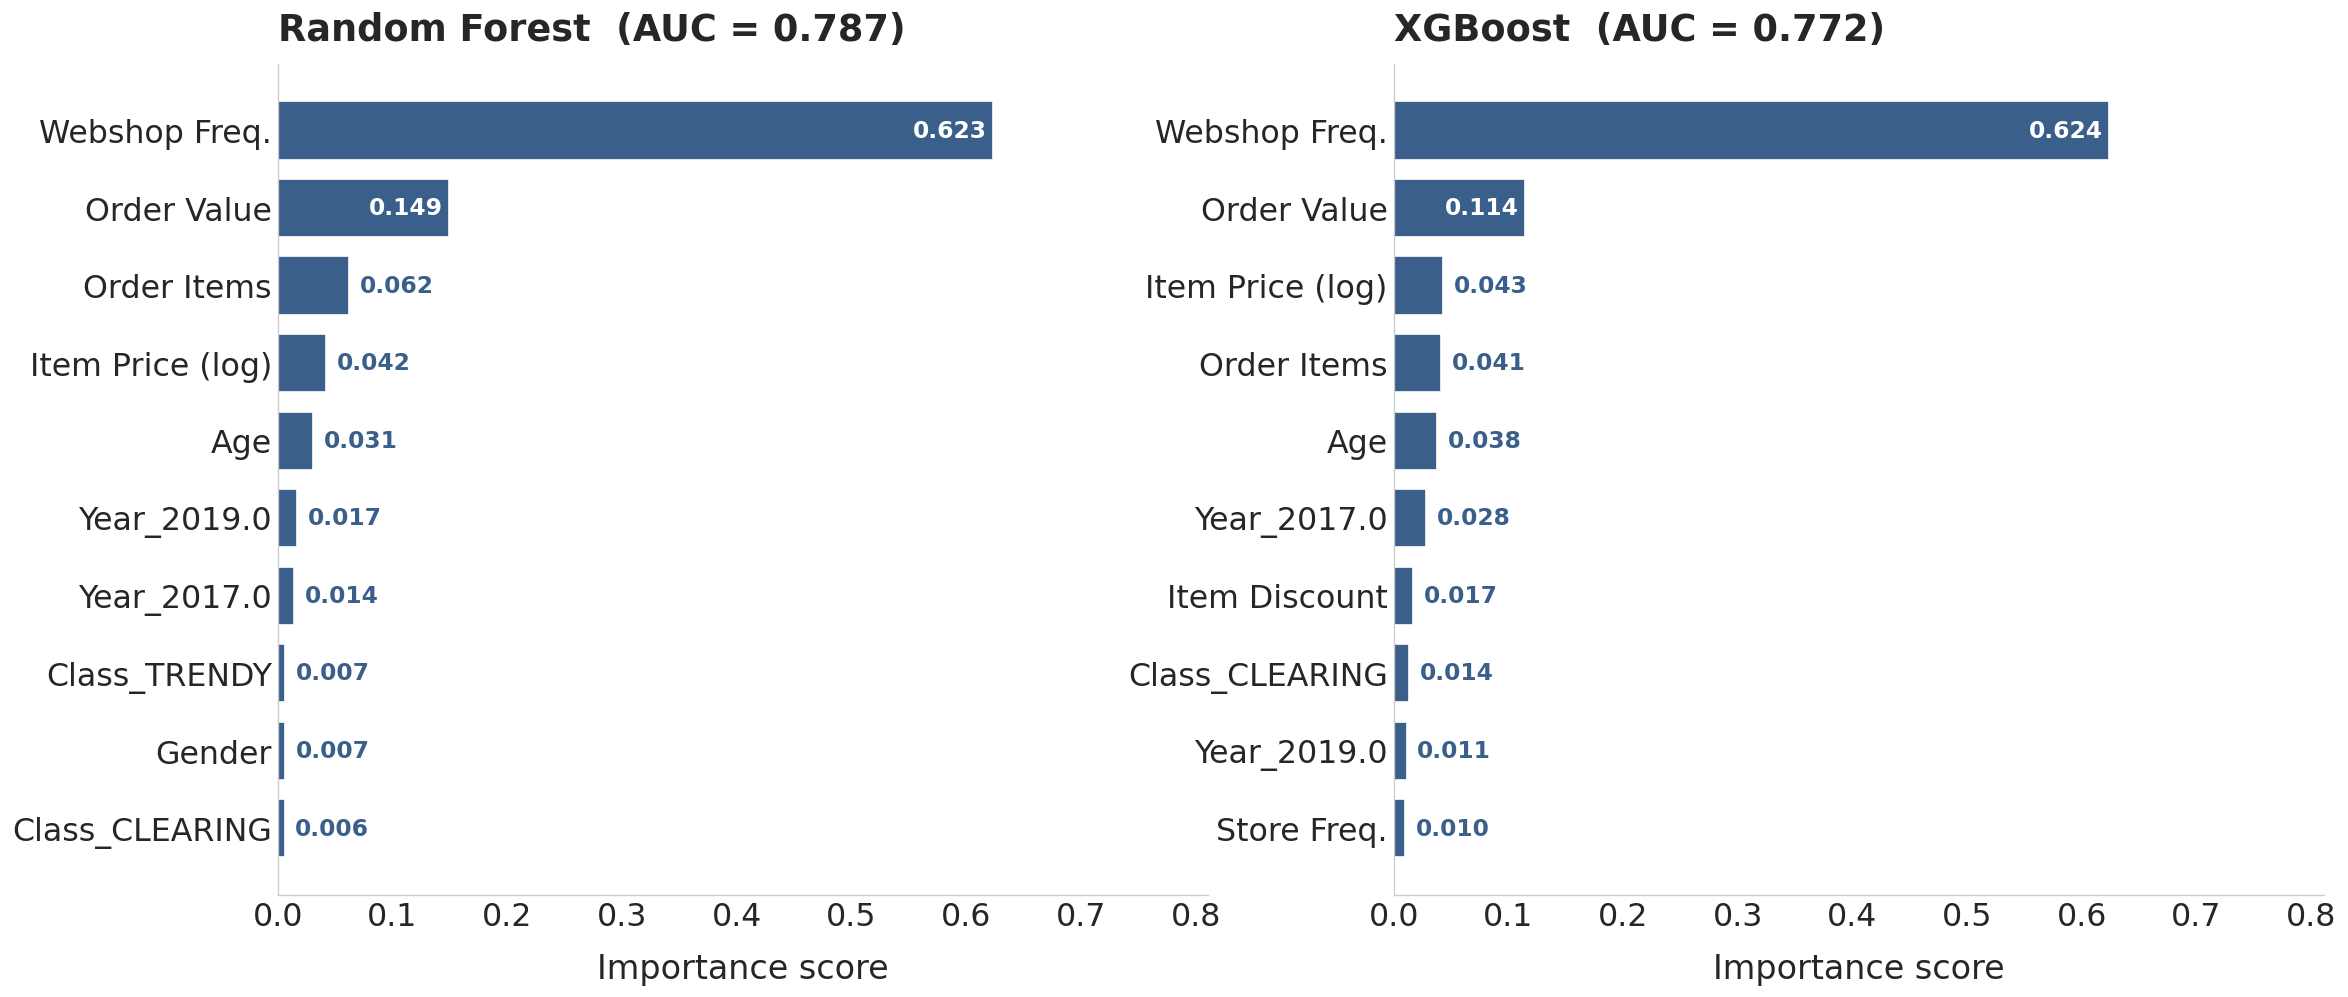

In [ ]:
top_n = 10
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
# ── Recompute imp_df (requires rf, xgb_imp from ML cells) ────────────────────
imp_df = pd.DataFrame({
    'Feature':        X.columns,
    'RF_Importance':  rf.feature_importances_,
    'XGB_Importance': xgb_imp
}).sort_values('RF_Importance', ascending=False)

print('Feature Importance — Top 10 (Random Forest):')
print(imp_df.head(10).to_string(index=False))

for ax, col, model_label, auc in zip(
    axes,
    ['RF_Importance', 'XGB_Importance'],
    ['Random Forest', 'XGBoost'],
    [rf_auc, xgb_auc]
):
    top = imp_df.nlargest(top_n, col).sort_values(col, ascending=True)
    feature_labels = (top['Feature']
        .str.replace('WebshopFrequency', 'Webshop Freq.')
        .str.replace('OrderValue',       'Order Value')
        .str.replace('OrderItems',       'Order Items')
        .str.replace('ItemPrice_log',    'Item Price (log)')
        .str.replace('ItemDiscount',     'Item Discount')
        .str.replace('OrderCoupon',      'Coupon Usage')
        .str.replace('Storefrequency',   'Store Freq.')
        .str.replace('FL_VERNIEUW',      'FL: VERNIEUW')
        .str.replace('FL_ACTUEEL',       'FL: ACTUEEL')
        .str.replace('Gender_num',       'Gender')
    )
    bars = ax.barh(range(len(top)), top[col],
                   color=SLATE, edgecolor=WHITE, height=0.75)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(feature_labels, fontsize=13)

    max_w = top[col].max()
    for bar in bars:
        w = bar.get_width()
        if w > 0.10:                                   
            ax.text(w - 0.005, bar.get_y() + bar.get_height()/2,
                    f'{w:.3f}', va='center', ha='right',
                    fontsize=14, color=WHITE, fontweight='bold')
        else:                                          
            ax.text(w + max_w * 0.015,                
                    bar.get_y() + bar.get_height()/2,
                    f'{w:.3f}', va='center', ha='left',
                    fontsize=14, color=SLATE,fontweight='bold' )

    ax.set_xlim(0, max_w * 1.30)                      
    ax.tick_params(axis='x', labelsize=12)
    apply_thesis_style(ax,
        title=f'{model_label}  (AUC = {auc:.3f})',
        xlabel='Importance score', ylabel='')

plt.savefig('fig7_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

---
## PART 6: Additional Analyses — Deeper Insights

### 6.1 Predicted Return Probability: Discount × Fashion Level

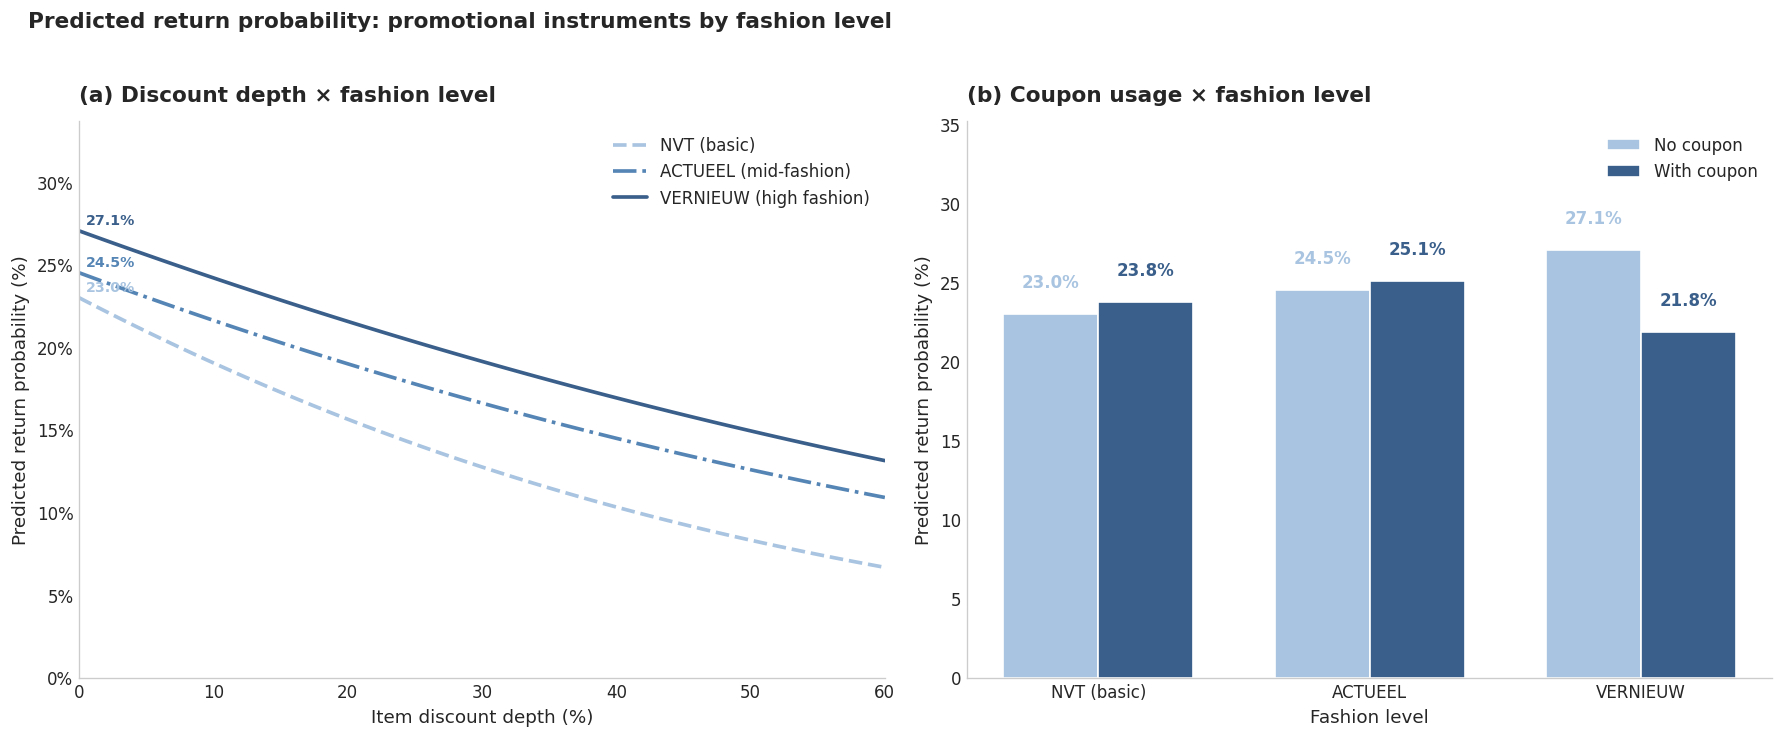

Saved: fig_pred_prob_combined.png


In [ ]:
# ── Figure: Predicted Return Probability — Discount & Coupon × Fashion Level ──
base_idx = (
    (df['ItemClass'] == df['ItemClass'].mode()[0]) &
    (df['Year']      == df['Year'].mode()[0]) &
    (df['Day']       == df['Day'].mode()[0])
).idxmax()

def make_pred_df(fl, discount_vals, coupon=0):
    rows = []
    for d in discount_vals:
        row = df.loc[[base_idx]].copy()
        row['ItemDiscount']            = d
        row['OrderCoupon']              = float(coupon)
        row['FL_ACTUEEL']              = 1.0 if fl == 'ACTUEEL'  else 0.0
        row['FL_VERNIEUW']             = 1.0 if fl == 'VERNIEUW' else 0.0
        row['Storefrequency_centered'] = 0.0
        row['Disc_x_ACTUEEL']          = d * row['FL_ACTUEEL'].values[0]
        row['Disc_x_VERNIEUW']         = d * row['FL_VERNIEUW'].values[0]
        row['Coup_x_ACTUEEL']          = float(coupon) * row['FL_ACTUEEL'].values[0]
        row['Coup_x_VERNIEUW']         = float(coupon) * row['FL_VERNIEUW'].values[0]
        row['Disc_x_Store']            = 0.0
        row['Coup_x_Store']            = 0.0
        rows.append(row)
    return pd.concat(rows, ignore_index=True)

discount_range = np.linspace(0, 60, 100)
fl_styles = {
    'NVT':      {'color': SLATE_L, 'ls': '--',  'label': 'NVT (basic)'},
    'ACTUEEL':  {'color': SLATE_M, 'ls': '-.',  'label': 'ACTUEEL (mid-fashion)'},
    'VERNIEUW': {'color': SLATE,   'ls': '-',   'label': 'VERNIEUW (high fashion)'},
}
fl_order  = ['NVT', 'ACTUEEL', 'VERNIEUW']
fl_labels = {'NVT': 'NVT (basic)', 'ACTUEEL': 'ACTUEEL', 'VERNIEUW': 'VERNIEUW'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel (a): Discount depth × Fashion level ──────────────────────────────────
ax = axes[0]
for fl, sty in fl_styles.items():
    pred_df = make_pred_df(fl, discount_range)
    probs   = m2.predict(pred_df) * 100
    ax.plot(discount_range, probs,
            color=sty['color'], linestyle=sty['ls'],
            linewidth=2.2, label=sty['label'])
    ax.annotate(f'{probs.iloc[0]:.1f}%',
                (0, probs.iloc[0]), xytext=(4, 4),
                textcoords='offset points',
                fontsize=8.5, color=sty['color'], fontweight='bold')

ax.set_xlim(0, 60)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
apply_thesis_style(ax,
    title='(a) Discount depth × fashion level',
    xlabel='Item discount depth (%)',
    ylabel='Predicted return probability (%)',
    legend=True)

# ── Panel (b): Coupon usage × Fashion level ────────────────────────────────────
ax = axes[1]
results = []
for fl in fl_order:
    for coupon in [0, 1]:
        pred_df = make_pred_df(fl, [0.0], coupon=coupon)
        prob    = m2.predict(pred_df)[0] * 100
        results.append({'FashionLevel': fl,
                        'Coupon': 'With coupon' if coupon else 'No coupon',
                        'Prob': prob})

res_df   = pd.DataFrame(results)
x        = np.arange(len(fl_order))
width    = 0.35
no_coup  = [res_df[(res_df['FashionLevel']==fl) & (res_df['Coupon']=='No coupon')]['Prob'].values[0] for fl in fl_order]
yes_coup = [res_df[(res_df['FashionLevel']==fl) & (res_df['Coupon']=='With coupon')]['Prob'].values[0] for fl in fl_order]

b1 = ax.bar(x - width/2, no_coup,  width, color=SLATE_L, edgecolor=WHITE, label='No coupon')
b2 = ax.bar(x + width/2, yes_coup, width, color=SLATE,   edgecolor=WHITE, label='With coupon')
label_bars(ax, b1, color=SLATE_L)
label_bars(ax, b2, color=SLATE)
ax.set_xticks(x)
ax.set_xticklabels([fl_labels[f] for f in fl_order], fontsize=11)
ax.set_ylim(0, max(yes_coup + no_coup) * 1.3)
apply_thesis_style(ax,
    title='(b) Coupon usage × fashion level',
    xlabel='Fashion level',
    ylabel='Predicted return probability (%)',
    legend=True)

plt.suptitle('Predicted return probability: promotional instruments by fashion level',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.02)
plt.tight_layout()
plt.savefig('fig_pred_prob_combined.png')
plt.show()
print('Saved: fig_pred_prob_combined.png')

### 6.3 Store Visitor vs Online-Only Customer Subgroup Analysis

── STORE VISITOR SUBGROUP ANALYSIS ──

Return rate by store experience:
                  n  return_rate
Online-Only    6336        18.67
Store Visitor   714        17.51

Chi-square test: χ²=0.501, df=1, p=0.4791

Return rate: StoreVisitor × Discount bucket:
 StoreVisitor      DiscBucket    n  return_rate
  Online-Only     No Discount 5155        19.09
  Online-Only     Low (1–15%)  615        16.75
  Online-Only Medium (16–30%)  433        17.09
  Online-Only     High (>30%)  133        16.54
Store Visitor     No Discount  515        18.25
Store Visitor     Low (1–15%)   80        11.25
Store Visitor Medium (16–30%)   84        16.67
Store Visitor     High (>30%)   35        22.86

Return rate: StoreVisitor × CouponUsed:
 StoreVisitor  CouponUsed    n  return_rate
  Online-Only   No Coupon 5863        18.42
  Online-Only Coupon Used  473        21.78
Store Visitor   No Coupon  637        16.80
Store Visitor Coupon Used   77        23.38


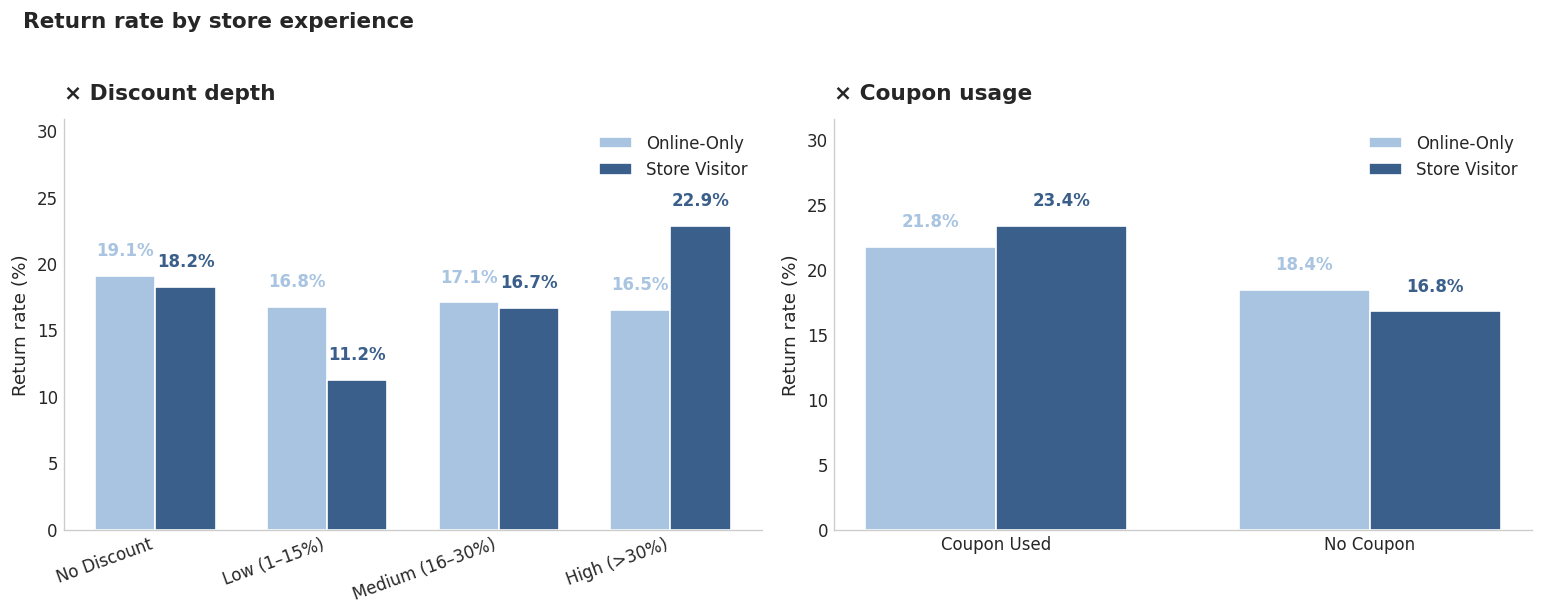

Saved: fig10_store_visitor_subgroup.png


In [ ]:
# ── 6.3 StoreVisitor binary split ────────────────────────────────────────────
print('── STORE VISITOR SUBGROUP ANALYSIS ──')

df['StoreVisitor'] = (df['Storefrequency'] > 0).astype(int)

# A. Return rate comparison
grp = df.groupby('StoreVisitor')['ItemReturn'].agg(n='count', return_rate='mean')
grp['return_rate'] = grp['return_rate'].mul(100).round(2)
grp.index = ['Online-Only', 'Store Visitor']
print('\nReturn rate by store experience:')
print(grp)

# Chi-square test
from scipy.stats import chi2_contingency, ttest_ind
ct = pd.crosstab(df['StoreVisitor'], df['ItemReturn'])
chi2, p_chi, dof, _ = chi2_contingency(ct)
print(f'\nChi-square test: χ²={chi2:.3f}, df={dof}, p={p_chi:.4f}')

# B. Promotion sensitivity: return rate by StoreVisitor × Discount bucket
df['DiscBucket'] = pd.cut(df['ItemDiscount'],
                           bins=[-0.01, 0, 15, 30, 200],
                           labels=['No Discount', 'Low (1–15%)', 'Medium (16–30%)', 'High (>30%)'])

print('\nReturn rate: StoreVisitor × Discount bucket:')
tbl = df.groupby(['StoreVisitor', 'DiscBucket'])['ItemReturn'].agg(
    n='count', return_rate='mean').reset_index()
tbl['StoreVisitor'] = tbl['StoreVisitor'].map({0: 'Online-Only', 1: 'Store Visitor'})
tbl['return_rate']  = tbl['return_rate'].mul(100).round(2)
print(tbl.to_string(index=False))

# C. Promotion sensitivity: return rate by StoreVisitor × Coupon
print('\nReturn rate: StoreVisitor × OrderCoupon:')
tbl2 = df.groupby(['StoreVisitor', 'OrderCoupon'])['ItemReturn'].agg(
    n='count', return_rate='mean').reset_index()
tbl2['StoreVisitor'] = tbl2['StoreVisitor'].map({0: 'Online-Only', 1: 'Store Visitor'})
tbl2['OrderCoupon']   = tbl2['OrderCoupon'].map({0: 'No Coupon', 1: 'Coupon Used'})
tbl2['return_rate']  = tbl2['return_rate'].mul(100).round(2)
print(tbl2.to_string(index=False))

# D. Visualisation — Styled
tbl_plot  = tbl.copy()
tbl_plot['StoreVisitor'] = tbl_plot['StoreVisitor'].astype(str)
tbl2_plot = tbl2.copy()
tbl2_plot['StoreVisitor'] = tbl2_plot['StoreVisitor'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, idx_col, title in [
    (axes[0], tbl_plot,  'DiscBucket', '× Discount depth'),
    (axes[1], tbl2_plot, 'OrderCoupon', '× Coupon usage'),
]:
    pivot = data.pivot(index=idx_col, columns='StoreVisitor', values='return_rate')
    x, w  = np.arange(len(pivot)), 0.35
    cols  = [c for c in ['Online-Only', 'Store Visitor', 'Online-only', 'Store visitor'] if c in pivot.columns]
    if len(cols) >= 2:
        b1 = ax.bar(x - w/2, pivot[cols[0]], w, color=SLATE_L, edgecolor=WHITE, label=cols[0])
        b2 = ax.bar(x + w/2, pivot[cols[1]], w, color=SLATE,   edgecolor=WHITE, label=cols[1])
        label_bars(ax, b1, color=SLATE_L)
        label_bars(ax, b2, color=SLATE)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=20 if len(pivot)>2 else 0, ha='right' if len(pivot)>2 else 'center', fontsize=9)
    ax.set_ylim(0, pivot.values.max() * 1.35)
    apply_thesis_style(ax, title=title, xlabel='', ylabel='Return rate (%)', legend=True)

plt.suptitle('Return rate by store experience', fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.02)
plt.tight_layout()
plt.savefig('fig10_store_visitor_subgroup.png')
plt.show()
print('Saved: fig10_store_visitor_subgroup.png')


### 6.4 Discount Bucket Analysis — Nonlinear Effects

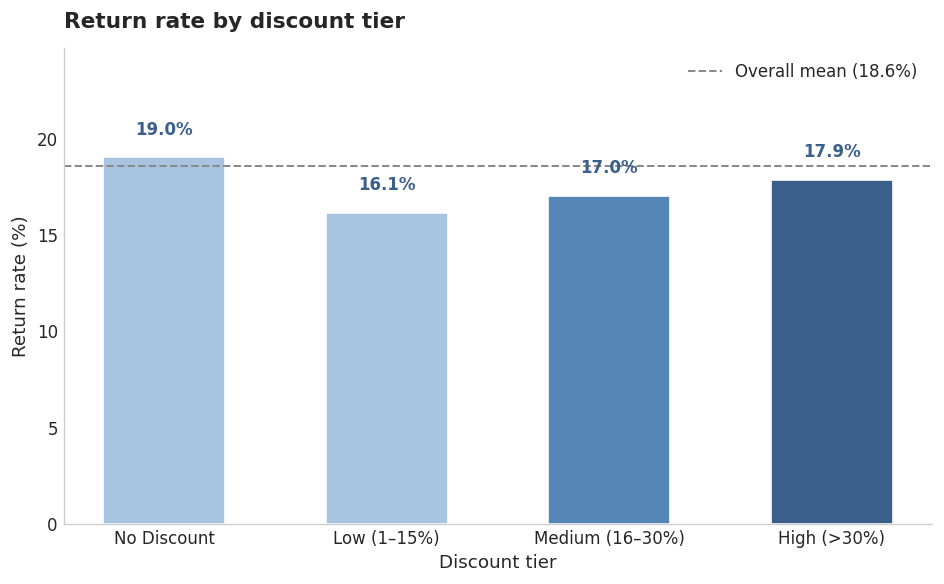

Saved: fig_discount_bucket.png


In [ ]:
# ── Figure: Discount Bucket Analysis (bar chart only) ─────────────────────────
if 'DiscBucket' not in df.columns:
    df['DiscBucket'] = pd.cut(df['ItemDiscount'],
        bins=[-0.01, 0, 15, 30, 200],
        labels=['No discount', 'Low (1–15%)', 'Medium (16–30%)', 'High (>30%)'])

buck = (
    df.groupby('DiscBucket', observed=True)['ItemReturn']
    .agg(n='count', return_rate='mean')
    .assign(return_rate=lambda x: x['return_rate'].mul(100).round(2))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
bar_cols = [SLATE_L, SLATE_L, SLATE_M, SLATE]
bars = ax.bar(buck['DiscBucket'].astype(str), buck['return_rate'],
              color=bar_cols, edgecolor=WHITE, width=0.55)
label_bars(ax, bars, color=SLATE)
ax.axhline(df['ItemReturn'].mean()*100, color=GRAY, linestyle='--',
           linewidth=1.2, label=f"Overall mean ({df['ItemReturn'].mean()*100:.1f}%)")
ax.set_ylim(0, buck['return_rate'].max() * 1.3)
apply_thesis_style(ax,
    title='Return rate by discount tier',
    xlabel='Discount tier', ylabel='Return rate (%)', legend=True)
plt.tight_layout()
plt.savefig('fig_discount_bucket.png')
plt.show()
print('Saved: fig_discount_bucket.png')


### 6.5 Year Trend Analysis

── YEAR TREND ANALYSIS ──

Return rate by Year × Fashion Level:
ItemFashionLevel  ACTUEEL    NVT  VERNIEUW
Year                                      
2013.0               4.76   0.00     28.57
2014.0               8.47   0.00     13.33
2015.0              11.11   7.14     19.23
2016.0              18.92   8.42     20.00
2017.0              17.66  10.33     21.55
2018.0              24.08   9.96     20.69
2019.0              29.06  14.77     27.55

Year-level promotional and return trends:
        return_rate  coupon_rate  disc_rate  avg_disc     n
Year                                                       
2013.0        10.34         0.00       0.00      0.00    29
2014.0         8.54         0.00       6.10      0.40    82
2015.0        12.69         0.00       5.08      1.17   197
2016.0        17.82         0.00      12.93      2.24   735
2017.0        16.85         0.00      17.70      3.75  3763
2018.0        20.02        23.88      30.28      5.85   984
2019.0        24.68       

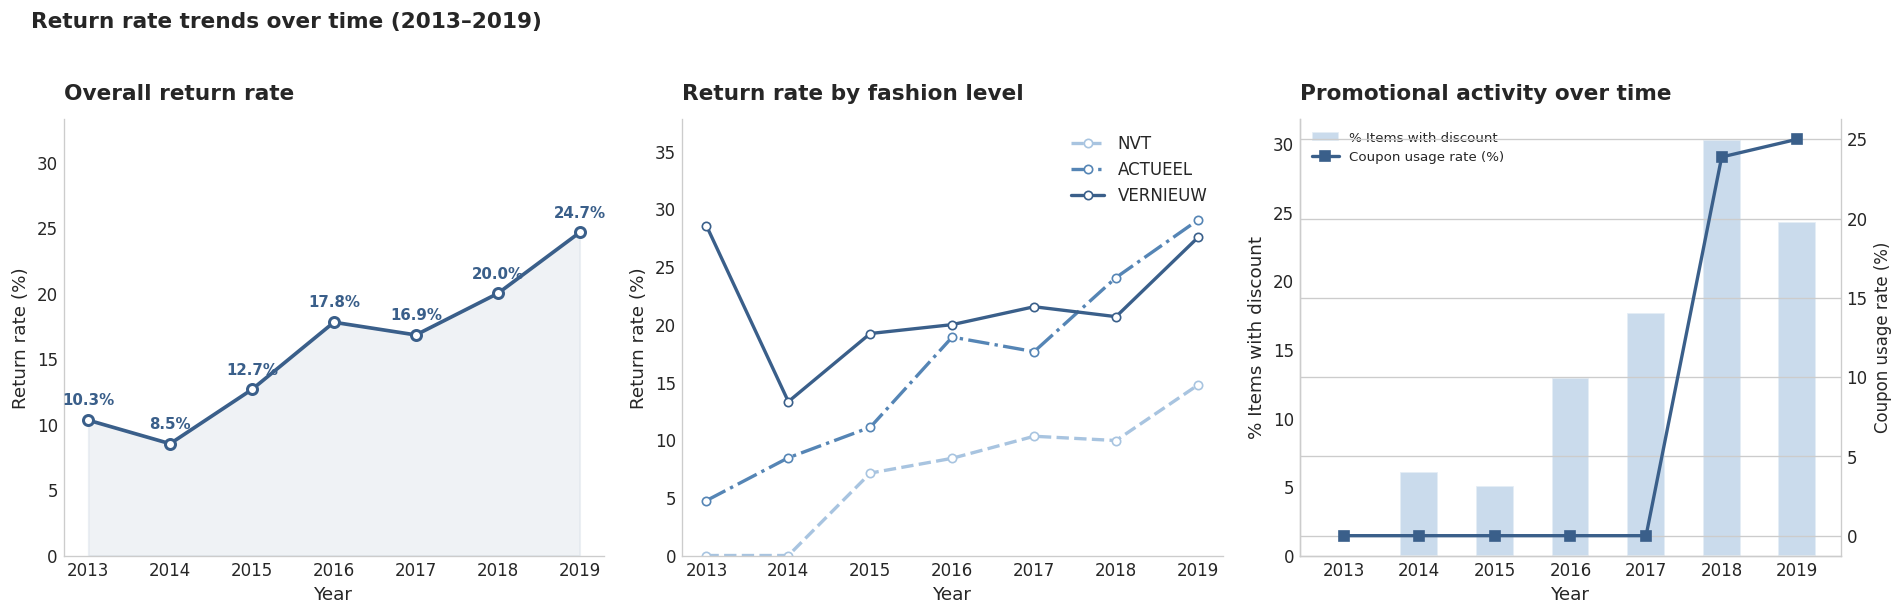

Saved: year_trend_analysis.png


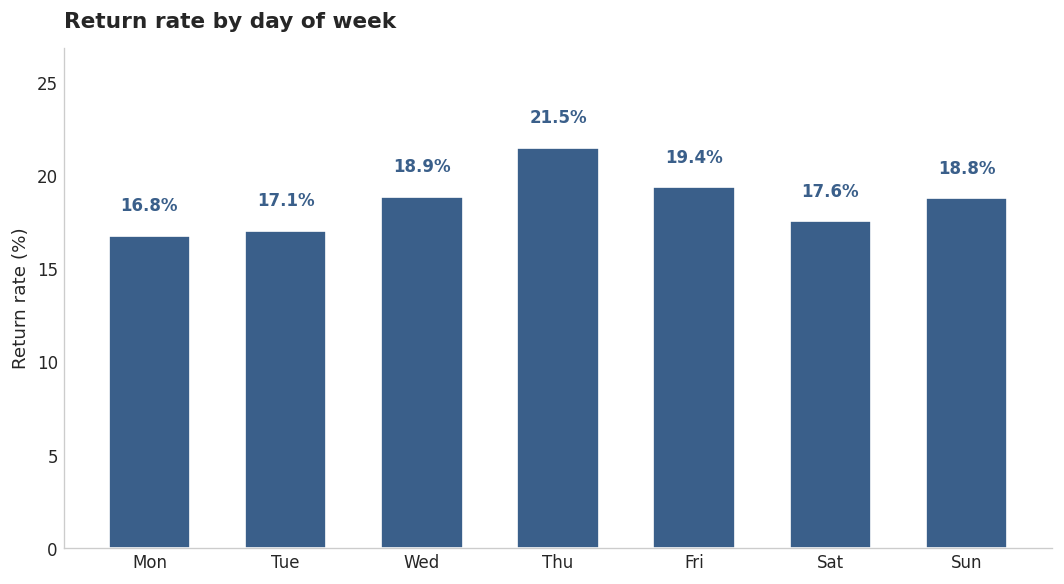

Saved: return_by_day.png


In [ ]:
# ── 6.5 Year trend: return rate × promotions × fashion level ────────────────
print('── YEAR TREND ANALYSIS ──')

# A. Return rate over time by FashionLevel
year_fl = df.groupby(['Year', 'ItemFashionLevel'])['ItemReturn'].mean().mul(100).round(2)
year_fl = year_fl.reset_index()
print('\nReturn rate by Year × Fashion Level:')
print(year_fl.pivot(index='Year', columns='ItemFashionLevel', values='ItemReturn').round(2))

# B. Coupon usage rate and return rate over time
year_promo = df.groupby('Year').agg(
    return_rate = ('ItemReturn',  'mean'),
    coupon_rate = ('OrderCoupon',  'mean'),
    disc_rate   = ('ItemDiscount', lambda x: (x > 0).mean()),
    avg_disc    = ('ItemDiscount', 'mean'),
    n           = ('ItemReturn',  'count')
).mul({'return_rate': 100, 'coupon_rate': 100, 'disc_rate': 100,
       'avg_disc': 1, 'n': 1}).round(2)
print('\nYear-level promotional and return trends:')
print(year_promo)

# ── Define years here ─────────────────────────────────────────────────────────
years = sorted(df['Year'].unique().tolist())

# C. Visualisation — Styled 3-panel
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Overall return rate trend
axes[0].plot(years, year_promo['return_rate'], marker='o', color=SLATE,
             linewidth=2.2, markersize=6, markerfacecolor=WHITE,
             markeredgecolor=SLATE, markeredgewidth=1.8)
axes[0].fill_between(years, year_promo['return_rate'], alpha=0.08, color=SLATE)
label_line(axes[0], years, year_promo['return_rate'], color=SLATE, offset=(0, 9))
axes[0].set_ylim(0, year_promo['return_rate'].max() * 1.35)
axes[0].set_xticks(years)
apply_thesis_style(axes[0], title='Overall return rate',
                   xlabel='Year', ylabel='Return rate (%)')

# Panel 2: Return rate by fashion level over time
fl_styles = {'NVT': (SLATE_L, '--'), 'ACTUEEL': (SLATE_M, '-.'), 'VERNIEUW': (SLATE, '-')}
for fl, (color, ls) in fl_styles.items():
    sub = year_fl[year_fl['ItemFashionLevel'] == fl]
    axes[1].plot(sub['Year'], sub['ItemReturn'], marker='o', label=fl,
                 color=color, linestyle=ls, linewidth=2, markersize=5,
                 markerfacecolor=WHITE, markeredgecolor=color)
axes[1].set_xticks(years)
axes[1].set_ylim(0, year_fl['ItemReturn'].max() * 1.3)
apply_thesis_style(axes[1], title='Return rate by fashion level',
                   xlabel='Year', ylabel='Return rate (%)', legend=True)

# Panel 3: Promotional activity
ax3b = axes[2].twinx()
axes[2].bar(years, year_promo['disc_rate'], color=SLATE_L, alpha=0.6,
            label='% Items with discount', width=0.5)
ax3b.plot(years, year_promo['coupon_rate'], marker='s', color=SLATE,
          linewidth=2, markersize=6, label='Coupon usage rate (%)')
ax3b.spines[['top']].set_visible(False)
ax3b.spines[['right']].set_color('#CCCCCC')
ax3b.tick_params(axis='y', length=0, labelsize=10)
apply_thesis_style(axes[2], title='Promotional activity over time',
                   xlabel='Year', ylabel='% Items with discount')
ax3b.set_ylabel('Coupon usage rate (%)', fontsize=10)
axes[2].set_xticks(years)
lines1, lab1 = axes[2].get_legend_handles_labels()
lines2, lab2 = ax3b.get_legend_handles_labels()
axes[2].legend(lines1+lines2, lab1+lab2, fontsize=8, frameon=False, loc='upper left')

plt.suptitle('Return rate trends over time (2013–2019)',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.02)
plt.tight_layout()
plt.savefig('year_trend_analysis.png')
plt.show()
print('Saved: year_trend_analysis.png')

# ── Day of week ────────────────────────────────────────────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr  = {
    'Monday':'Mon', 'Tuesday':'Tue', 'Wednesday':'Wed',
    'Thursday':'Thu', 'Friday':'Fri', 'Saturday':'Sat', 'Sunday':'Sun'
}

day_ret = df.groupby('Day')['ItemReturn'].agg(n='count', return_rate='mean')
day_ret['return_rate'] = day_ret['return_rate'].mul(100).round(2)

# Sort by Mon → Sun
day_ret = day_ret.loc[[d for d in day_order if d in day_ret.index]]

#  Abbreviate day names for plotting
day_ret.index = [day_abbr.get(d, d) for d in day_ret.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(day_ret.index, day_ret['return_rate'],
              color=SLATE, edgecolor=WHITE, width=0.6)
label_bars(ax, bars, color=SLATE)
ax.set_ylim(0, float(day_ret['return_rate'].max()) * 1.25)
apply_thesis_style(ax,
    title='Return rate by day of week',
    xlabel='', ylabel='Return rate (%)')
plt.tight_layout()
plt.savefig('return_by_day.png')
plt.show()
print('Saved: return_by_day.png')

### 6.6 Gender × Promotion Interaction

── GENDER × PROMOTION ANALYSIS ──

Return rate: Gender × Discount bucket:
Gender      DiscBucket    n  return_rate
Female     No Discount 4886        20.02
Female     Low (1–15%)  633        15.48
Female Medium (16–30%)  449        17.82
Female     High (>30%)  146        19.18
  Male     No Discount  784        12.76
  Male     Low (1–15%)   62        22.58
  Male Medium (16–30%)   68        11.76
  Male     High (>30%)   22         9.09

Return rate: Gender × CouponUsed:
Gender CouponUsed    n  return_rate
Female  No Coupon 5621        19.23
Female     Coupon  493        20.89
  Male  No Coupon  879        12.06
  Male     Coupon   57        31.58

Gender × Promotion interactions (exploratory):
  Variable                 Coef   exp(β)    p-value   Sig
  ItemDiscount          -0.0177   0.9824     0.1990      
  CouponUsed             0.8934   2.4433     0.0264     *
  Disc_x_Female          0.0015   1.0015     0.9152      
  Coup_x_Female         -1.0503   0.3498     0.0133     *


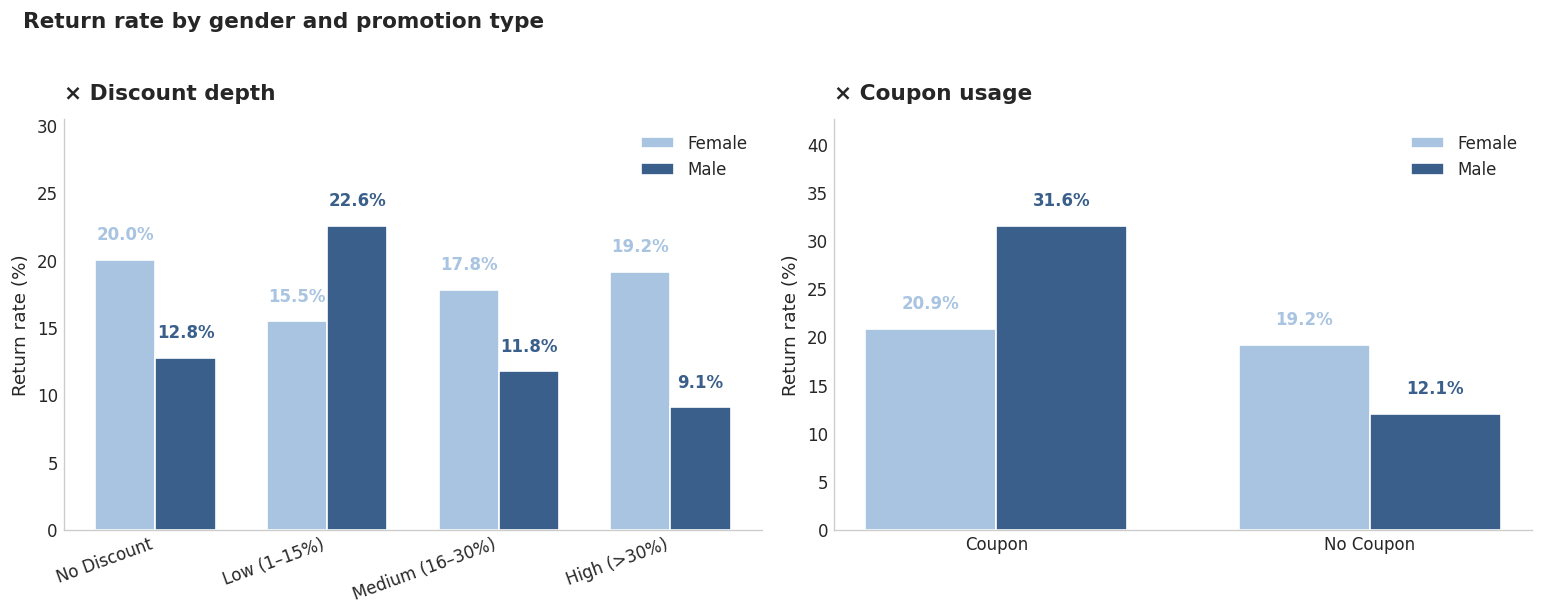

Saved: gender_promotion_analysis.png


In [ ]:
# ── 6.6 Gender × Promotion ───────────────────────────────────────────────────
print('── GENDER × PROMOTION ANALYSIS ──')

# A. Descriptive
print('\nReturn rate: Gender × Discount bucket:')
tbl_g1 = df.groupby(['Gender', 'DiscBucket'])['ItemReturn'].agg(
    n='count', return_rate='mean').reset_index()
tbl_g1['return_rate'] = tbl_g1['return_rate'].mul(100).round(2)
print(tbl_g1.to_string(index=False))

print('\nReturn rate: Gender × OrderCoupon:')
tbl_g2 = df.groupby(['Gender', 'OrderCoupon'])['ItemReturn'].agg(
    n='count', return_rate='mean').reset_index()
tbl_g2['OrderCoupon']   = tbl_g2['OrderCoupon'].map({0: 'No Coupon', 1: 'Coupon'})
tbl_g2['return_rate']  = tbl_g2['return_rate'].mul(100).round(2)
print(tbl_g2.to_string(index=False))

# B. Regression with Gender interactions (robustness / exploratory)
df['Disc_x_Female'] = df['ItemDiscount'] * df['Gender_num']
df['Coup_x_Female'] = df['OrderCoupon']   * df['Gender_num']

f_gender = (
    f"ItemReturn ~ ItemDiscount + OrderCoupon + Disc_x_Female + Coup_x_Female + "
    f"FL_ACTUEEL + FL_VERNIEUW + Storefrequency_centered + {controls}"
)
m_gender = smf.logit(f_gender, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': cluster}, disp=False)

print('\nGender × Promotion interactions (exploratory):')
print(f"  {'Variable':<20} {'Coef':>8} {'exp(β)':>8} {'p-value':>10} {'Sig':>5}")
for var in ['ItemDiscount', 'OrderCoupon', 'Disc_x_Female', 'Coup_x_Female']:
    if var in m_gender.params:
        coef = m_gender.params[var]
        expb = np.exp(coef)
        pval = m_gender.pvalues[var]
        sig  = ('***' if pval < 0.001 else '**' if pval < 0.01 else
                '*'   if pval < 0.05  else '.'  if pval < 0.1  else '')
        print(f"  {var:<20} {coef:>8.4f} {expb:>8.4f} {pval:>10.4f} {sig:>5}")

# C. Visualisation — Styled
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, idx_col, title in [
    (axes[0], tbl_g1, 'DiscBucket', '× Discount depth'),
    (axes[1], tbl_g2, 'OrderCoupon', '× Coupon usage'),
]:
    pivot = data.pivot(index=idx_col, columns='Gender', values='return_rate')
    x, w  = np.arange(len(pivot)), 0.35
    genders = pivot.columns.tolist()
    b1 = ax.bar(x - w/2, pivot[genders[0]], w, color=SLATE_L, edgecolor=WHITE, label=genders[0])
    b2 = ax.bar(x + w/2, pivot[genders[1]], w, color=SLATE,   edgecolor=WHITE, label=genders[1])
    label_bars(ax, b1, color=SLATE_L)
    label_bars(ax, b2, color=SLATE)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=20 if len(pivot)>2 else 0, ha='right' if len(pivot)>2 else 'center', fontsize=9)
    ax.set_ylim(0, pivot.values.max() * 1.35)
    apply_thesis_style(ax, title=title, xlabel='', ylabel='Return rate (%)', legend=True)

plt.suptitle('Return rate by gender and promotion type', fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.02)
plt.tight_layout()
plt.savefig('gender_promotion_analysis.png')
plt.show()
print('Saved: gender_promotion_analysis.png')


### 6.7 Order-Level Analysis

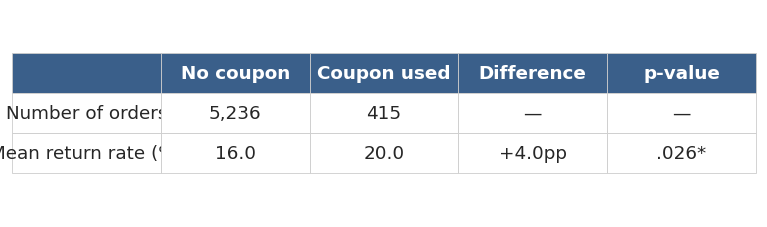

In [ ]:
# ── Table 7: Order-Level Return Rate by Coupon Usage ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 2.2))
ax.axis('off')

col_labels = ['', 'No coupon', 'Order coupon', 'Difference', 'p-value']
row_data = [
    ['Number of orders', '5,236', '415', '—', '—'],
    ['Mean return rate (%)', '16.0', '20.0', '+4.0pp', '.026*'],
]

table = ax.table(
    cellText=row_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

# ── Style cells ───────────────────────────────────────────────────────────────
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    cell.set_linewidth(0.5)

    # Header row
    if row == 0:
        cell.set_facecolor(SLATE)
        cell.set_text_props(color=WHITE, fontweight='bold')

    # First column


In [ ]:
# ── Summary printout ──────────────────────────────────────────────────────────
print('=' * 60)
print('ADDITIONAL ANALYSES COMPLETE')
print('=' * 60)
print('Figures saved:')
print('  pred_prob_discount_fl.png    — 6.1 Discount × FashionLevel')
print('  pred_prob_coupon_fl.png      — 6.2 Coupon × FashionLevel')
print('  store_visitor_subgroup.png   — 6.3 Store Visitor subgroup')
print('  discount_bucket_analysis.png — 6.4 Discount buckets')
print('  year_trend_analysis.png      — 6.5 Year trends')
print('  gender_promotion_analysis.png— 6.6 Gender × Promotion')
print('  order_level_analysis.png     — 6.7 Order-level')


In [ ]:
#Full M1 coefficients for Appendix Table A1
import pandas as pd

summary = m1_full.summary2().tables[1][['Coef.', 'Std.Err.', 'P>|z|']].round(3)
summary.columns = ['β', 'SE', 'p']
summary.index.name = 'Variable'

# Remove Day and Year dummies from summary for Appendix Table A1
fe_cols = [c for c in summary.index if 'Day' in c or 'Year' in c]
summary_clean = summary.drop(fe_cols)

print(summary_clean.to_string())
print(f"\nN = {int(m1_full.nobs)}")
print(f"AIC = {m1_full.aic:.1f}")
print(f"Pseudo-R2 = {m1_full.prsquared:.3f}")
print(f"Log-likelihood = {m1_full.llf:.2f}")

                                                       β     SE      p
Variable                                                              
Intercept                                         -2.379  0.712  0.001
C(ItemFashionLevel, Treatment('NVT'))[T.ACTUEEL]   0.073  0.138  0.598
C(ItemFashionLevel, Treatment('NVT'))[T.VERNIEUW]  0.188  0.146  0.197
C(ItemClass)[T.CLEARING]                           1.048  0.257  0.000
C(ItemClass)[T.MODERN]                             0.912  0.265  0.001
C(ItemClass)[T.POPULAIR]                           0.952  0.387  0.014
C(ItemClass)[T.SHOE CAR]                          -0.351  0.675  0.603
C(ItemClass)[T.STREET]                             0.507  0.305  0.097
C(ItemClass)[T.TRENDY]                             0.487  0.233  0.037
ItemDiscount                                      -0.016  0.004  0.000
CouponUsed                                        -0.052  0.146  0.721
Storefrequency_centered                            0.132  0.121  0.273
OrderV

In [ ]:
# ── AUC of Logistic Regression M1 to compare with ML ─────────────────────────
from sklearn.metrics import roc_auc_score

# Predicted probabilities from M1
y_true = df['ItemReturn'].values
y_pred_m1 = m1_full.predict(df)

auc_m1 = roc_auc_score(y_true, y_pred_m1)
print(f"Logistic Regression M1 AUC: {auc_m1:.3f}")
print(f"Random Forest AUC:          0.787")
print(f"XGBoost AUC:                0.772")
print(f"Improvement RF over M1:     {0.787 - auc_m1:.3f}")

Logistic Regression M1 AUC: 0.729
Random Forest AUC:          0.787
XGBoost AUC:                0.772
Improvement RF over M1:     0.058
